In [1]:
library(ComplexHeatmap)
library(circlize)
#library(gridExtra)
library(RColorBrewer)
library(ggpubr)
library(tidyverse)
library(ggplot2)
library(dplyr)
library(corrplot)
library(circlize)
library(stringr)
library(tidyr)
library(ggpubr)
library(readr)
library(rstatix)

Loading required package: grid

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.16
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements a

In [2]:
setwd("/scratch/mjehangir/gliomas_subtypes/")
#setwd("/scratch/mjehangir/gliomas_subtypes/new_data/")


In [3]:
library(readr)
library(dplyr)

path <- "/home/mjehangir/softwares/Arm-Level-Aneuploidy/data/genomic_arm_coordinates_hg19.txt"

arm_lengths <- read_tsv(path, col_types = cols(), comment = "#") %>%
  # make sure we use dplyr's verbs
  dplyr::rename(arm_start = start, arm_end = end) %>%
  dplyr::mutate(
    # ensure chr prefix
    chrom = ifelse(grepl("^chr", chrom), chrom, paste0("chr", chrom)),
    arm_length = arm_end - arm_start
  ) %>%
  dplyr::select(chrom, side, arm, arm_start, arm_end, arm_length)

head(arm_lengths)


chrom,side,arm,arm_start,arm_end,arm_length
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
chr1,p,1p,0.00e+00,125000000,125000000
chr1,q,1q,1.25e+08,249250621,124250621
chr10,p,10p,0.00e+00,40200000,40200000
chr10,q,10q,4.02e+07,135534747,95334747
chr11,p,11p,0.00e+00,53700000,53700000
chr11,q,11q,5.37e+07,135006516,81306516


In [4]:


genome_size <- sum(arm_lengths$arm_length)

# Load CNV data as before
files <- list.files(pattern = "_(primary|recurrence).seg$")
cnv_all <- do.call(rbind, lapply(files, function(file) {
  df <- read.table(file, header = TRUE, sep = "\t")
  df$tumor_type <- case_when(
    grepl("astro", file, ignore.case = TRUE) ~ "Astrocytoma",
    grepl("oligo", file, ignore.case = TRUE) ~ "Oligodendroglioma",
    grepl("glioblastoma", file, ignore.case = TRUE) ~ "GBM",
    TRUE ~ "Other"
  )
  df$stage <- ifelse(grepl("primary", file, ignore.case = TRUE), "Primary", "Recurrence")
  df$sample <- df$ID
  df$row_id <- paste0(file, "_", seq_len(nrow(df)))  # unique id
  df
}))

cnv_all <- cnv_all %>%
  mutate(chrom = ifelse(grepl("^chr", chrom), chrom, paste0("chr", chrom)),
         segment_length = loc.end - loc.start)

# Join with arm coordinates & calculate overlap
cnv_with_arms <- cnv_all %>%
  left_join(arm_lengths, by = "chrom") %>%
  filter(loc.start < arm_end & loc.end > arm_start) %>%
  mutate(
    overlap_start = pmax(loc.start, arm_start),
    overlap_end = pmin(loc.end, arm_end),
    overlap_len = pmax(0, overlap_end - overlap_start),
    arm_fraction = overlap_len / arm_length
  )
head(cnv_with_arms)


Warning message in left_join(., arm_lengths, by = "chrom"):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


,ID,chrom,loc.start,loc.end,num.mark,seg.mean,tumor_type,stage,sample,row_id,segment_length,side,arm,arm_start,arm_end,arm_length,overlap_start,overlap_end,overlap_len,arm_fraction
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TCGA-CS-4938-01,chr1,3218610,91104026,50505,0.0027,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_1,87885416,p,1p,0.00e+00,125000000,125000000,3218610,91104026,87885416,0.703083328
2,TCGA-CS-4938-01,chr1,91108204,91109793,2,-1.3703,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_2,1589,p,1p,0.00e+00,125000000,125000000,91108204,91109793,1589,0.000012712
3,TCGA-CS-4938-01,chr1,91112769,247813706,78501,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_3,156700937,p,1p,0.00e+00,125000000,125000000,91112769,125000000,33887231,0.271097848
4,TCGA-CS-4938-01,chr1,91112769,247813706,78501,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_3,156700937,q,1q,1.25e+08,249250621,124250621,125000000,247813706,122813706,0.988435350
5,TCGA-CS-4938-01,chr2,484222,106146307,55667,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_4,105662085,p,2p,0.00e+00,93300000,93300000,484222,93300000,92815778,0.994810054
6,TCGA-CS-4938-01,chr2,484222,106146307,55667,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_4,105662085,q,2q,9.33e+07,243199373,149899373,93300000,106146307,12846307,0.085699538


In [5]:
unique(cnv_with_arms$stage)


[1] "Primary"    "Recurrence"

In [6]:
mean(cnv_with_arms$seg.mean)
median(cnv_with_arms$seg.mean)

[1] -0.5588372

[1] -0.095477

In [7]:
#arm_level_threshold <- 0.3
arm_level_threshold <- 0.3


cnv_with_arms <- cnv_with_arms %>%
  mutate(
    cna_status = ifelse(seg.mean > 0, 1, ifelse(seg.mean < 0, -1, 0))
  )


In [8]:
library(dplyr)

# Assume cnv_with_arms is the input data frame
# Define the threshold for arm-level aneuploidy
threshold <- 0.8

# 1. Filter for CNV segments that are gains or losses (cna_status = 1 or -1)
cnv_alt <- cnv_with_arms %>% 
  filter(cna_status %in% c(1, -1))

In [9]:
# install.packages("conflicted")
library(conflicted)
conflict_prefer("first",  "dplyr")
conflict_prefer("rename", "dplyr")
conflict_prefer("mutate", "dplyr")
conflict_prefer("filter", "dplyr")
conflict_prefer("select", "dplyr")


[conflicted] Will prefer dplyr::first over any other package.
[conflicted] Will prefer dplyr::rename over any other package.
[conflicted] Will prefer dplyr::mutate over any other package.
[conflicted] Will prefer dplyr::filter over any other package.
[conflicted] Will prefer dplyr::select over any other package.


In [10]:
head(cnv_alt)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean,tumor_type,stage,sample,row_id,⋯,side,arm,arm_start,arm_end,arm_length,overlap_start,overlap_end,overlap_len,arm_fraction,cna_status
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TCGA-CS-4938-01,chr1,3218610,91104026,50505,0.0027,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_1,⋯,p,1p,0.00e+00,125000000,125000000,3218610,91104026,87885416,0.703083328,1
2,TCGA-CS-4938-01,chr1,91108204,91109793,2,-1.3703,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_2,⋯,p,1p,0.00e+00,125000000,125000000,91108204,91109793,1589,0.000012712,-1
3,TCGA-CS-4938-01,chr1,91112769,247813706,78501,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_3,⋯,p,1p,0.00e+00,125000000,125000000,91112769,125000000,33887231,0.271097848,1
4,TCGA-CS-4938-01,chr1,91112769,247813706,78501,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_3,⋯,q,1q,1.25e+08,249250621,124250621,125000000,247813706,122813706,0.988435350,1
5,TCGA-CS-4938-01,chr2,484222,106146307,55667,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_4,⋯,p,2p,0.00e+00,93300000,93300000,484222,93300000,92815778,0.994810054,1
6,TCGA-CS-4938-01,chr2,484222,106146307,55667,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_4,⋯,q,2q,9.33e+07,243199373,149899373,93300000,106146307,12846307,0.085699538,1


In [11]:
cnv_with_arms_primary = cnv_with_arms %>% filter(stage == "Primary")

In [12]:
# Total unique samples
total_samples <- length(unique(cnv_alt$sample))
total_samples

# Count of samples per tumor subtype
table(cnv_alt$stage)


[1] 760


   Primary Recurrence 
    112110     140545 

In [16]:
library(dplyr)
library(tidyr)

# Summarize unique samples by tumor type and stage
summary_table <- cnv_alt %>%
  group_by(tumor_type, stage) %>%
  summarise(unique_samples = n_distinct(sample), .groups = 'drop') %>%
  pivot_wider(names_from = stage, values_from = unique_samples, values_fill = 0) %>%
  mutate(Total = Primary + Recurrence)

# Add a row for the overall total
total_row <- tibble(
  tumor_type = "Total",
  Primary = sum(summary_table$Primary),
  Recurrence = sum(summary_table$Recurrence),
  Total = sum(summary_table$Total)
)

final_table <- bind_rows(summary_table, total_row)
final_table


tumor_type,Primary,Recurrence,Total
<chr>,<int>,<int>,<int>
Astrocytoma,130,78,208
GBM,174,205,379
Oligodendroglioma,126,47,173
Total,430,330,760


In [13]:
library(dplyr)

# Count unique samples per tumor type
samples_per_type <- cnv_alt %>%
  group_by(tumor_type) %>%
  summarise(unique_samples = n_distinct(sample))

samples_per_type


tumor_type,unique_samples
<chr>,<int>
Astrocytoma,208
GBM,379
Oligodendroglioma,173


In [15]:
library(dplyr)
library(tidyr)

# Summarize unique samples per tumor type and stage
sample_counts <- cnv_alt %>%
  group_by(tumor_type, stage) %>%
  summarise(unique_samples = n_distinct(sample), .groups = 'drop') %>%
  pivot_wider(names_from = stage, values_from = unique_samples, values_fill = 0) %>%
  mutate(Total_Samples = Primary + Recurrence)

# Summarize SV counts per tumor type
sv_counts <- cnv_alt %>%
  group_by(tumor_type, type) %>%
  summarise(total_SVs = n(), .groups = 'drop') %>%
  pivot_wider(names_from = type, values_from = total_SVs, values_fill = 0)

# Combine sample counts and SV counts
final_summary <- sample_counts %>%
  left_join(sv_counts, by = "tumor_type") %>%
  mutate(Total_SVs = DEL + DUP + INS + INV)

# Add overall total row
total_row <- final_summary %>%
  summarise(
    tumor_type = "Total",
    Primary = sum(Primary),
    Recurrence = sum(Recurrence),
    Total_Samples = sum(Total_Samples),
    DEL = sum(DEL),
    DUP = sum(DUP),
    INS = sum(INS),
    INV = sum(INV),
    Total_SVs = sum(Total_SVs)
  )

final_table <- bind_rows(final_summary, total_row)
final_table


ERROR: [1m[33mError[39m in `group_by()`:[22m
[1m[22m[33m![39m Must group by variables found in `.data`.
[31m✖[39m Column `type` is not found.


In [558]:
nrow(cnv_with_arms)

[1] 112116

In [559]:
nrow(cnv_with_arms_primary)

[1] 112116

In [560]:
unique(cnv_with_arms_primary$stage)

[1] "Primary"

In [561]:
cnv_with_arms_all = cnv_with_arms

In [562]:
nrow(cnv_with_arms_all)

[1] 112116

In [563]:
cnv_with_arms = cnv_with_arms_primary 

In [564]:
nrow(cnv_with_arms)

[1] 112116

In [599]:
library(dplyr)
library(tidyr)

# --------------------------
# PARAMETERS (tweak as needed)
# --------------------------
aneuploidy_threshold <- 0.80      # arm-level threshold (Taylor-like)
segmean_threshold    <- 0.30      # |seg.mean| to call a segment "altered" if cna_status is unreliable
prefer_cna_status    <- FALSE     # set TRUE if cnv_with_arms$cna_status is trustworthy (nonzero = altered)

# --------------------------
# INPUT
#   Expect columns at least:
#   ID, tumor_type, arm, arm_length, overlap_len, seg.mean, (optional) cna_status
#   Each row is a segment–arm overlap with length 'overlap_len'
# --------------------------
df <- cnv_with_arms %>%
  mutate(
    arm_length = as.numeric(arm_length),
    overlap_len = as.numeric(overlap_len),
    seg.mean   = as.numeric(seg.mean),
    cna_status = suppressWarnings(as.numeric(cna_status))
  ) %>%
  mutate(
    is_altered = if (prefer_cna_status && any(!is.na(cna_status))) {
      cna_status != 0
    } else {
      abs(seg.mean) >= segmean_threshold
    }
  )

In [600]:
# --------------------------
# PER-ARM SUMMARY (per sample × arm)
#   - Sum altered bp on this arm
#   - Compute fraction altered
#   - Call aneuploid if >= threshold
# --------------------------
arm_summary <- df %>%
  group_by(ID, tumor_type, arm) %>%
  summarise(
    arm_length = max(arm_length, na.rm = TRUE),               # robust to 'first' issues
    altered_bp = sum(overlap_len[is_altered], na.rm = TRUE)
  , .groups = "drop") %>%
  mutate(
    altered_bp    = pmin(altered_bp, arm_length),             # cap at arm size
    frac_altered  = ifelse(is.finite(arm_length) & arm_length > 0,
                           altered_bp / arm_length, NA_real_),
    is_aneuploid  = frac_altered >= aneuploidy_threshold
  )

In [601]:
# --------------------------
# PER-SAMPLE SCORES
#   1) n_aneuploid_arms
#   2) segmental_cnv_burden:
#        fraction of genome altered by sub-arm CNVs (i.e., altered bp on non-aneuploid arms / total arm bp)
# --------------------------
sample_scores <- arm_summary %>%
  group_by(ID, tumor_type) %>%
  summarise(
    n_aneuploid_arms      = sum(is_aneuploid, na.rm = TRUE),
    segmental_bp          = sum(altered_bp[!is_aneuploid], na.rm = TRUE),
    total_arm_bp          = sum(arm_length, na.rm = TRUE),
    segmental_cnv_burden  = segmental_bp / total_arm_bp       # 0–1 scale
  , .groups = "drop") %>%
  arrange(tumor_type, ID)

In [602]:
# OUTPUT
# --------------------------
head(sample_scores)
#write.csv(sample_scores, "/home/mjehangir/telomere-sv-analysis/data/tcga_gliomas_sample_aneuplidy_cnv_scores.csv", row.names = FALSE)


ID,tumor_type,n_aneuploid_arms,segmental_bp,total_arm_bp,segmental_cnv_burden
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
TCGA-CS-4938-01,Astrocytoma,1,136420978,2798633286,0.048745571
TCGA-CS-4942-01,Astrocytoma,2,114151701,2798633286,0.040788374
TCGA-CS-4943-01,Astrocytoma,4,254330672,2798633286,0.090876741
TCGA-CS-4944-01,Astrocytoma,1,66351435,2798633286,0.023708513
TCGA-CS-5393-01,Astrocytoma,1,108212087,2798633286,0.038666047
TCGA-CS-5394-01,Astrocytoma,1,23686426,2798633286,0.008463569


In [603]:
# Packages
if (!requireNamespace("ggforce", quietly = TRUE)) install.packages("ggforce")
if (!requireNamespace("ggpubr",  quietly = TRUE)) install.packages("ggpubr")
library(ggplot2)
library(ggforce)  # for geom_sina (sinaplot)
library(ggpubr)   # for stat_compare_means
library(dplyr)

# Data (expects your data frame 'sample_scores' as shown)
dat <- sample_scores %>%
  filter(!is.na(tumor_type), !is.na(n_aneuploid_arms)) %>%
  mutate(
    tumor_type = factor(tumor_type)  # keep current order; set levels() if you want a custom order
  )

# Build all pairwise comparisons dynamically
lvls <- levels(dat$tumor_type)
comps <- combn(lvls, 2, simplify = FALSE)

# Y positions for brackets
max_y <- max(dat$n_aneuploid_arms, na.rm = TRUE)
step  <- max(1, ceiling(0.08 * max_y))  # vertical spacing between brackets
label_y_pairs <- max_y + seq_along(comps) * step
label_y_global <- max_y + (length(comps) + 2) * step  # global test above pairwise

set.seed(123)  # for reproducible point jittering in sina



Warning message:
“`position_dodge()` requires non-overlapping x intervals.”
Warning message:
“`position_dodge()` requires non-overlapping x intervals.”


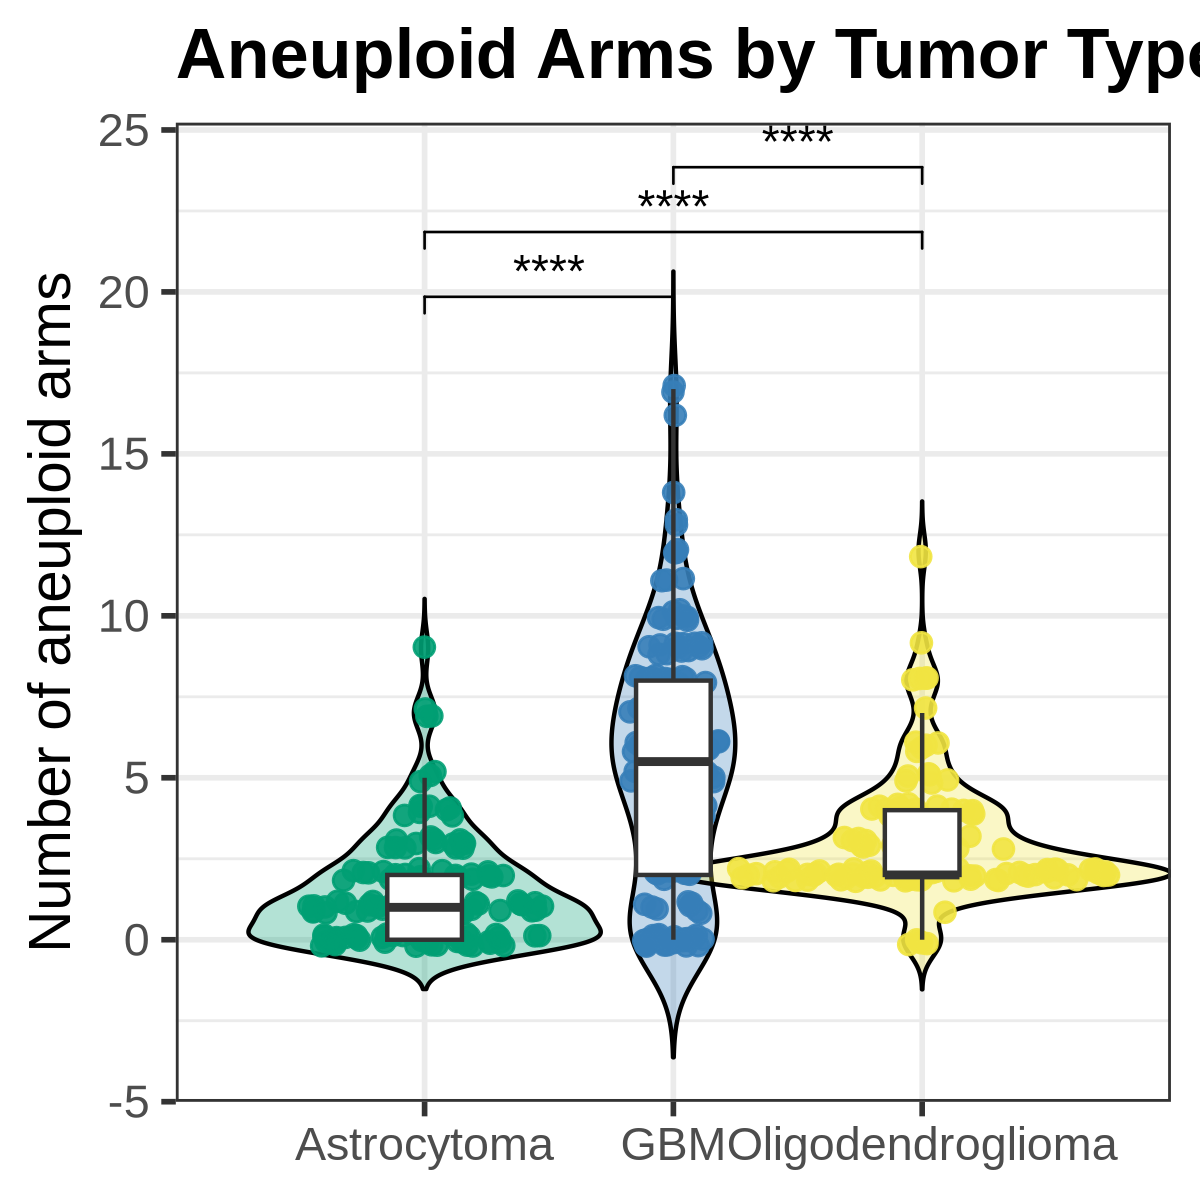

In [604]:
library(ggplot2)
library(ggforce)
library(ggpubr)
library(dplyr)

pal <- c(
  "Astrocytoma"       = "#009E73",
  "GBM"               = "#377EB8",
  "Oligodendroglioma" = "#F0E442"
)

dat <- sample_scores %>%
  filter(!is.na(tumor_type), !is.na(n_aneuploid_arms)) %>%
  mutate(tumor_type = factor(tumor_type, levels = names(pal)))

lvls <- levels(dat$tumor_type)
comps <- combn(lvls, 2, simplify = FALSE)
max_y <- max(dat$n_aneuploid_arms, na.rm = TRUE)
step  <- max(1, ceiling(0.08 * max_y))
label_y_pairs <- max_y + seq_along(comps) * step

# ---- counts for labels ----
counts <- dat %>% count(tumor_type, name = "n")
lab_fun <- function(x) paste0(x, " (n=", counts$n[match(x, counts$tumor_type)], ")")

p <- ggplot(dat, aes(x = tumor_type, y = n_aneuploid_arms, fill = tumor_type)) +
  geom_violin(alpha = 0.3, trim = FALSE, width = 2, color = "black") +
  ggforce::geom_sina(aes(color = tumor_type), alpha = 0.9, size = 2, maxwidth = 1.5) +
  geom_boxplot(fill = "white", width = 0.3, outlier.shape = NA) +
  stat_compare_means(
    comparisons = comps, method = "wilcox.test", p.adjust.method = "BH",
    label = "p.signif", hide.ns = TRUE, label.y = label_y_pairs
  ) +
  scale_fill_manual(values = pal) +
  scale_color_manual(values = pal) +
  #scale_x_discrete(labels = lab_fun) +   # <— add n to x-axis labels
  labs(x = NULL, y = "Number of aneuploid arms", title = "Aneuploid Arms by Tumor Type") +
  theme_bw(base_size = 14) +
  theme(legend.position = "none", plot.title = element_text(face = "bold"))

options(repr.plot.width = 4, repr.plot.height = 4, repr.plot.res = 300)

p


In [605]:
n_pos <- dat %>%
  group_by(tumor_type) %>%
  summarise(y = max(n_aneuploid_arms, na.rm = TRUE) + step * 0.6, n = n(), .groups = "drop")

p <- p +
  geom_text(data = n_pos,
            aes(x = tumor_type, y = y, label = paste0("n=", n), color = tumor_type),
            inherit.aes = FALSE, vjust = 0, fontface = "bold", size = 4) +
  expand_limits(y = max(n_pos$y) + step * 0.4)

Warning message:
“`position_dodge()` requires non-overlapping x intervals.”
Warning message:
“`position_dodge()` requires non-overlapping x intervals.”


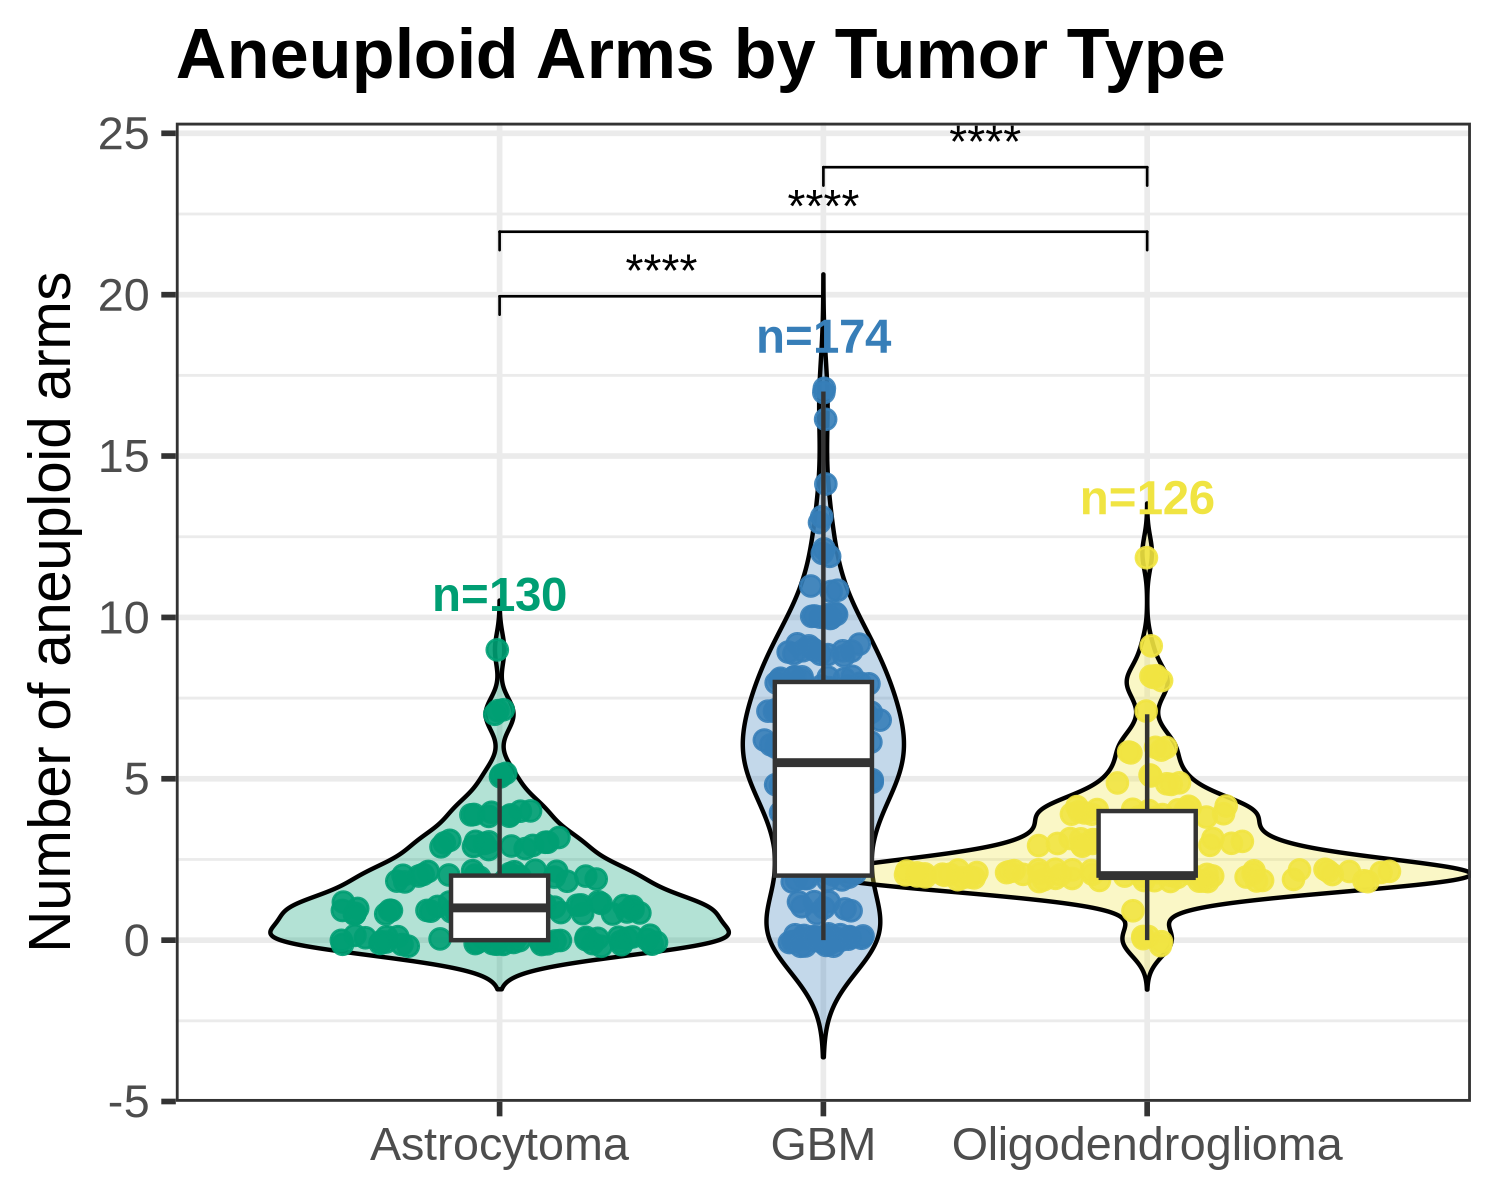

In [606]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 300)

p
# Or save to PDF
#ggsave("/home/mjehangir/telomere-sv-analysis/plots/TCGA_plots/aneuploid_arms_by_tumor.pdf", p, width = 5, height = 4)

In [607]:
library(ggplot2)
library(ggforce)
library(ggpubr)
library(dplyr)

pal <- c(
  "Astrocytoma"       = "#009E73",
  "GBM"               = "#377EB8",
  "Oligodendroglioma" = "#F0E442"
)

dat <- sample_scores %>%
  filter(!is.na(tumor_type), !is.na(segmental_cnv_burden)) %>%
  mutate(tumor_type = factor(tumor_type, levels = names(pal)))

# pairwise comparisons + positions
lvls <- levels(dat$tumor_type)
comps <- combn(lvls, 2, simplify = FALSE)
max_y2 <- max(dat$segmental_cnv_burden, na.rm = TRUE)
step2  <- max(0.02, 0.08 * max_y2)            # spacing for brackets on a 0–1-ish scale
label_y_pairs2 <- max_y2 + seq_along(comps) * step2

# counts for x-axis labels
counts <- dat %>% count(tumor_type, name = "n")
lab_fun <- function(x) paste0(x, " (n=", counts$n[match(x, counts$tumor_type)], ")")

p2 <- ggplot(dat, aes(x = tumor_type, y = segmental_cnv_burden, fill = tumor_type)) +
  geom_violin(alpha = 0.3, trim = FALSE, width = 2, color = "black") +
  ggforce::geom_sina(aes(color = tumor_type), alpha = 0.9, size = 2, maxwidth = 1.5) +
  geom_boxplot(fill = "white", width = 0.3, outlier.shape = NA) +
  stat_compare_means(
    comparisons = comps, method = "wilcox.test", p.adjust.method = "BH",
    label = "p.signif", hide.ns = TRUE, label.y = label_y_pairs2
  ) +
  scale_fill_manual(values = pal) +
  scale_color_manual(values = pal) +
  #scale_x_discrete(labels = lab_fun) +
  labs(
    x = NULL,
    y = "Segmental CNV burden",
    title = "Segmental CNV Burden by Tumor Type"
  ) +
  theme_bw(base_size = 14) +
  theme(legend.position = "none", plot.title = element_text(face = "bold")) +
  expand_limits(y = max(label_y_pairs2) + step2)

Warning message:
“`position_dodge()` requires non-overlapping x intervals.”
Warning message:
“`position_dodge()` requires non-overlapping x intervals.”


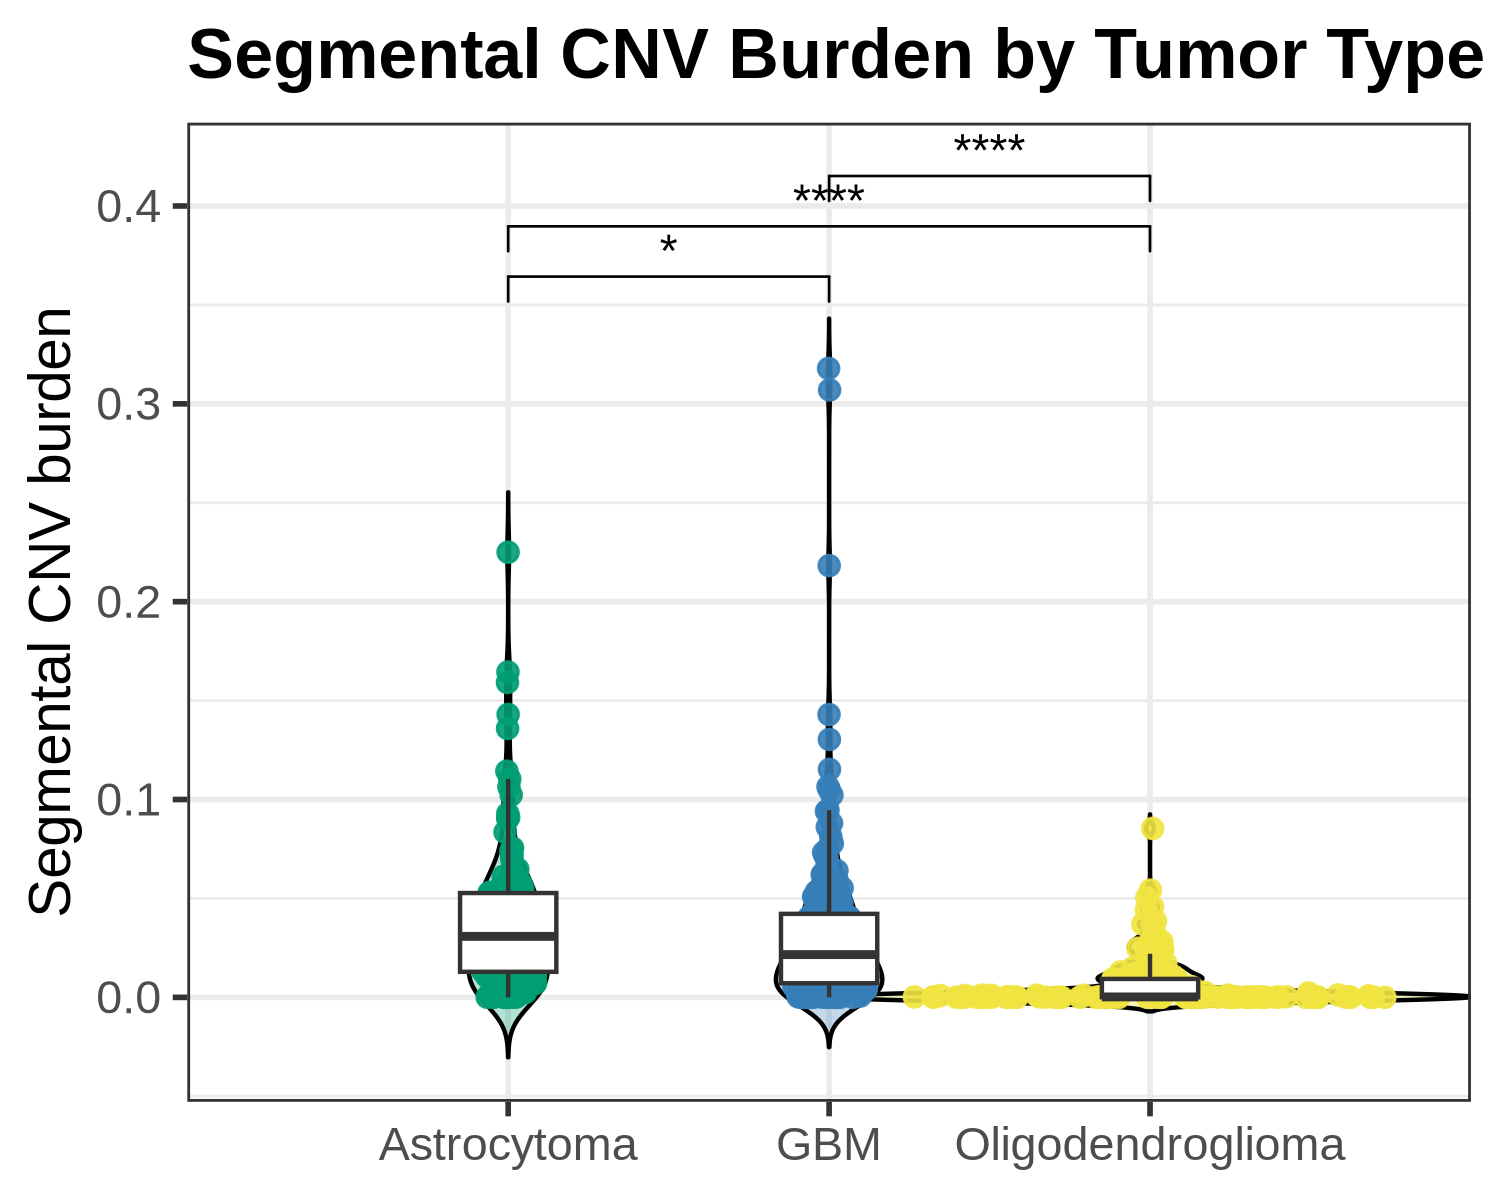

In [608]:
options(repr.plot.width = 5, repr.plot.height = 4, repr.plot.res = 300)

p2
#ggsave("/home/mjehangir/telomere-sv-analysis/plots/TCGA_plots/segmental_CNVs_burden_by_tumor.pdf", p2, width = 5, height = 4)

In [609]:
# Counts + y positions for segmental_cnv_burden
n_pos2 <- dat %>%
  group_by(tumor_type) %>%
  summarise(y = max(segmental_cnv_burden, na.rm = TRUE) + step2 * 0.6,
            n = n(), .groups = "drop")

# Add to the plot
p2 <- p2 +
  geom_text(
    data = n_pos2,
    aes(x = tumor_type, y = y, label = paste0("n=", n), color = tumor_type),
    inherit.aes = FALSE, vjust = 0, fontface = "bold", size = 4
  ) +
  expand_limits(y = max(n_pos2$y) + step2 * 0.4)

Warning message:
“`position_dodge()` requires non-overlapping x intervals.”
Warning message:
“`position_dodge()` requires non-overlapping x intervals.”


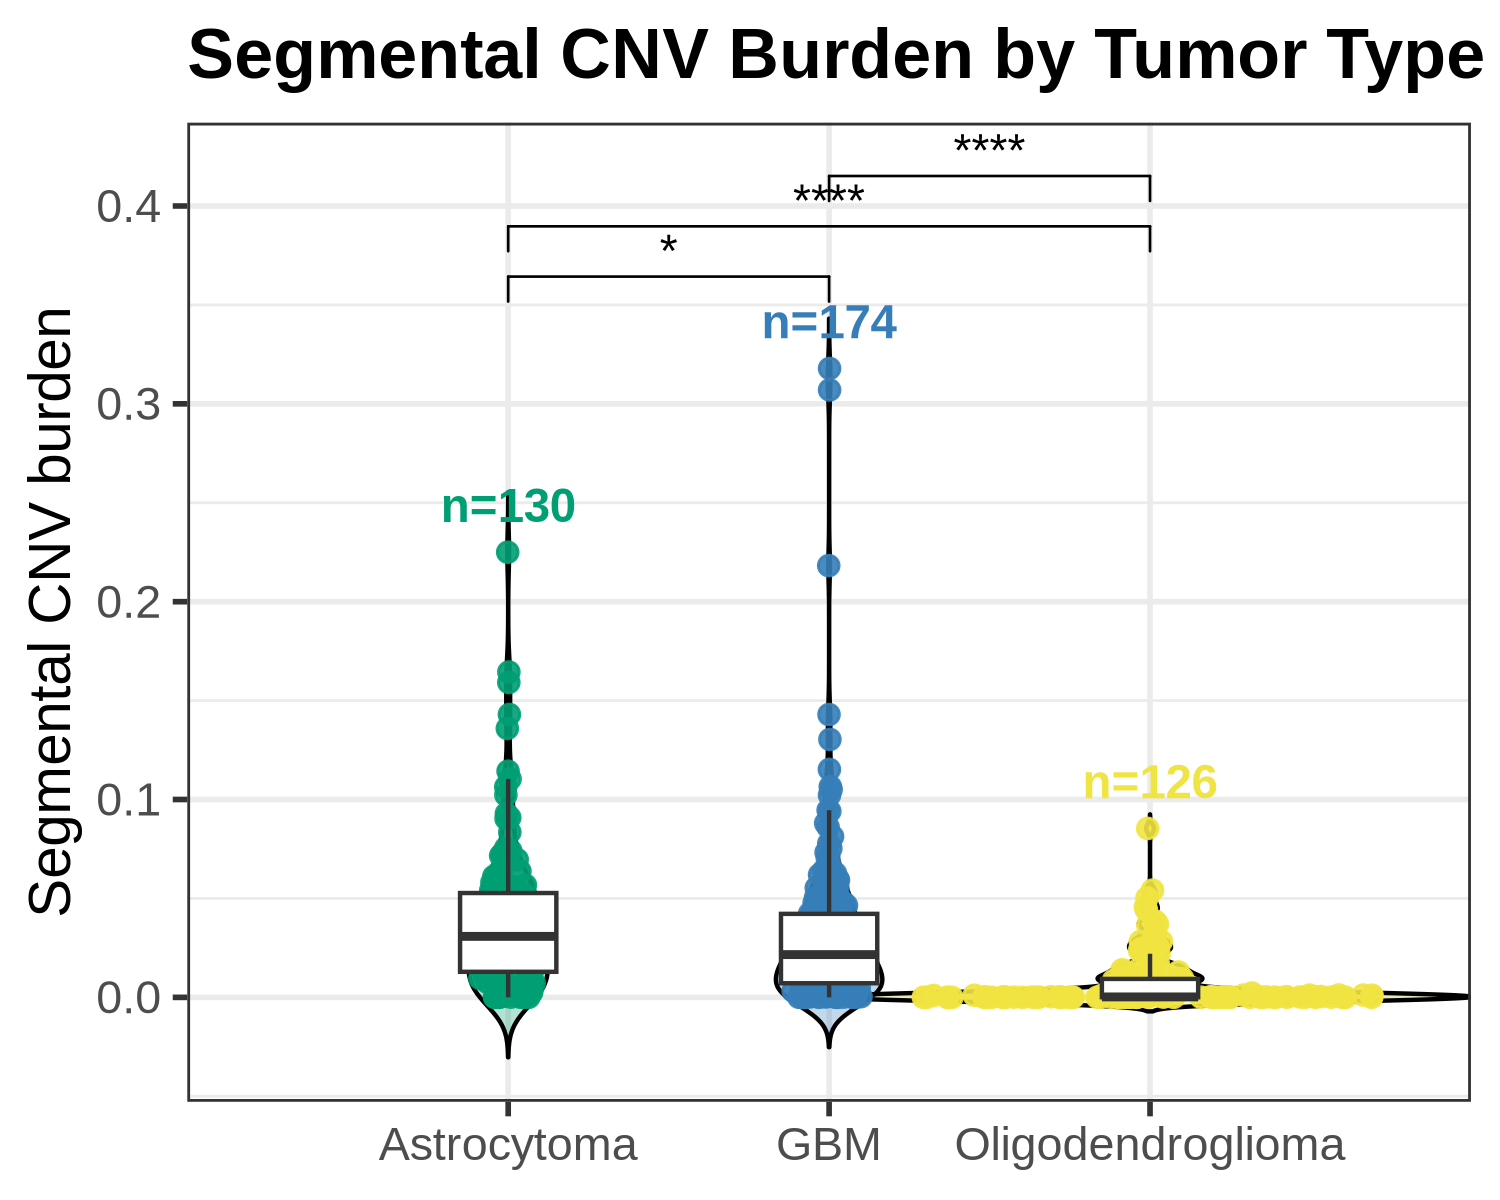

In [610]:
p2

In [611]:
head(sample_scores)

ID,tumor_type,n_aneuploid_arms,segmental_bp,total_arm_bp,segmental_cnv_burden
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
TCGA-CS-4938-01,Astrocytoma,1,136420978,2798633286,0.048745571
TCGA-CS-4942-01,Astrocytoma,2,114151701,2798633286,0.040788374
TCGA-CS-4943-01,Astrocytoma,4,254330672,2798633286,0.090876741
TCGA-CS-4944-01,Astrocytoma,1,66351435,2798633286,0.023708513
TCGA-CS-5393-01,Astrocytoma,1,108212087,2798633286,0.038666047
TCGA-CS-5394-01,Astrocytoma,1,23686426,2798633286,0.008463569


In [612]:
library(ggplot2)
library(dplyr)

# Palette (same as before)
pal <- c(
  "Astrocytoma"       = "#009E73",
  "GBM"               = "#377EB8",
  "Oligodendroglioma" = "#F0E442"
)

dat <- sample_scores %>%
  filter(!is.na(tumor_type), !is.na(n_aneuploid_arms)) %>%
  mutate(tumor_type = factor(tumor_type, levels = names(pal)))

# n per tumor_type for facet labels
counts <- dat %>% count(tumor_type, name = "n")
facet_labs <- setNames(
  paste0(levels(dat$tumor_type), " (n=", counts$n[match(levels(dat$tumor_type), counts$tumor_type)], ")"),
  levels(dat$tumor_type)
)

# Per-group median (and mean if you want another line)
grp_stats <- dat %>%
  group_by(tumor_type) %>%
  summarise(median_val = median(n_aneuploid_arms, na.rm = TRUE),
            mean_val   = mean(n_aneuploid_arms, na.rm = TRUE),
            .groups = "drop")

# --------- HISTOGRAMS (one per tumor type) ----------
p_hist <- ggplot(dat, aes(x = n_aneuploid_arms, fill = tumor_type)) +
  geom_histogram(binwidth = 1, boundary = -0.5, alpha = 0.6, color = "black") +
  geom_vline(data = grp_stats, aes(xintercept = median_val, color = tumor_type),
             #geom_vline(data = grp_stats, aes(xintercept = mean_val, color = tumor_type),
             linetype = 2, linewidth = 0.8, show.legend = FALSE) +
  scale_fill_manual(values = pal) +
  scale_color_manual(values = pal) +
  scale_x_continuous(breaks = scales::pretty_breaks()) +
  facet_wrap(~ tumor_type, ncol = 1, scales = "free_y",
             labeller = labeller(tumor_type = facet_labs)) +
  labs(
    x = "Number of aneuploid arms",
    y = "Sample count",
    title = "Distribution of Aneuploid Arms per Sample"
  ) +
  theme_bw(base_size = 14) +
  theme(
    legend.position = "none",
    strip.text = element_text(face = "bold")
  )

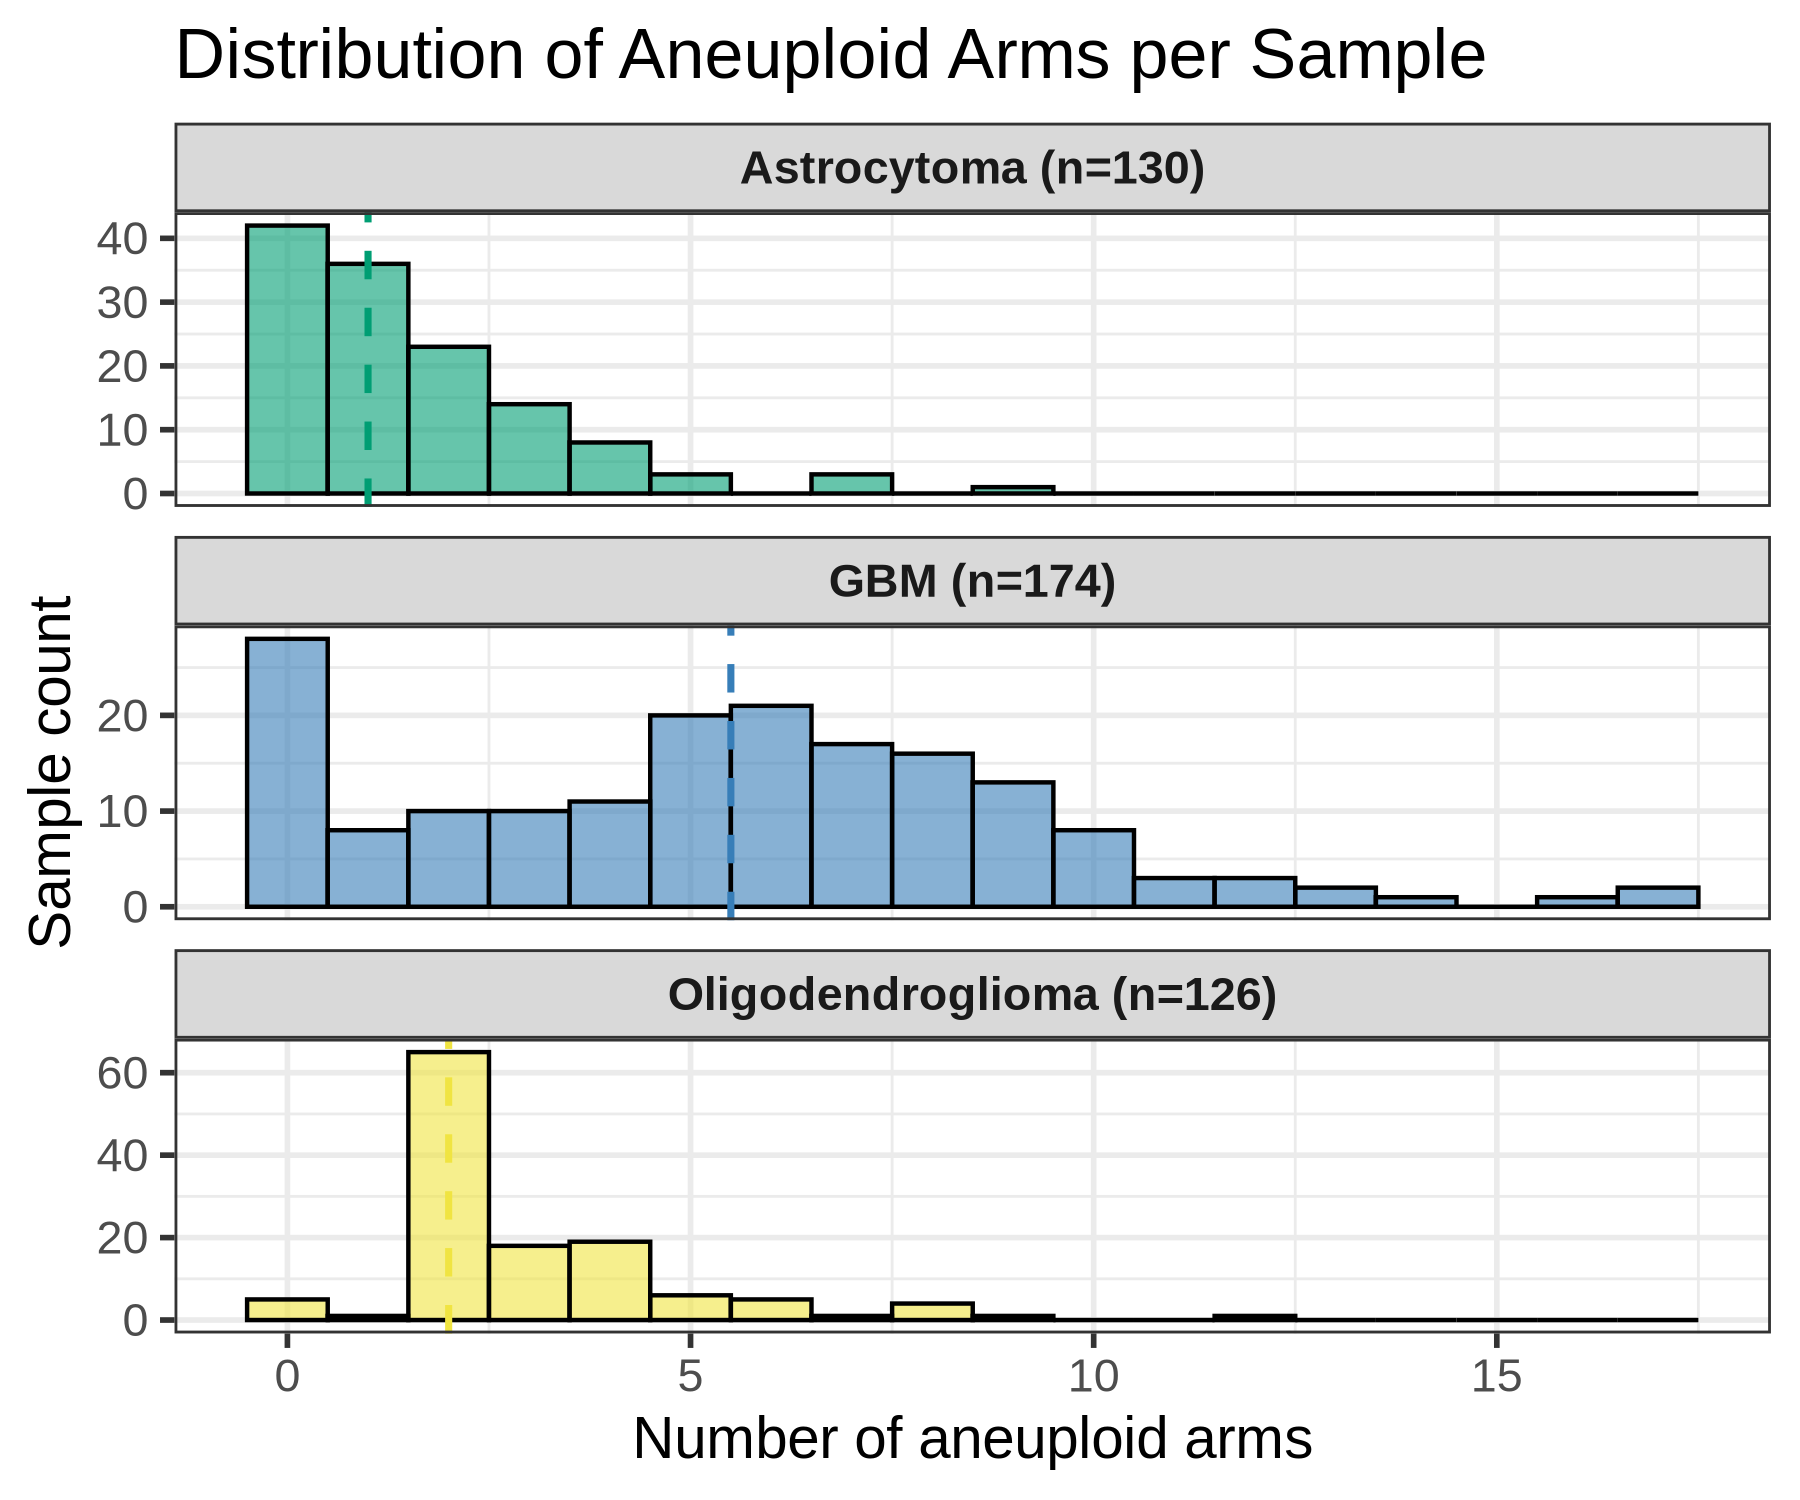

In [613]:
options(repr.plot.width = 6, repr.plot.height = 5, repr.plot.res = 300)
p_hist

In [614]:
library(ggplot2)
library(dplyr)

# Palette (same as before)
pal <- c(
  "Astrocytoma"       = "#009E73",
  "GBM"               = "#377EB8",
  "Oligodendroglioma" = "#F0E442"
)

# Data for burden plot
dat_burden <- sample_scores %>%
  filter(!is.na(tumor_type), !is.na(segmental_cnv_burden)) %>%
  mutate(tumor_type = factor(tumor_type, levels = names(pal)))

# Facet labels with n
counts2 <- dat_burden %>% count(tumor_type, name = "n")
facet_labs2 <- setNames(
  paste0(levels(dat_burden$tumor_type),
         " (n=", counts2$n[match(levels(dat_burden$tumor_type), counts2$tumor_type)], ")"),
  levels(dat_burden$tumor_type)
)

# Group stats (median line)
grp_stats2 <- dat_burden %>%
  group_by(tumor_type) %>%
  summarise(median_val = median(segmental_cnv_burden, na.rm = TRUE),
            .groups = "drop")

# Histogram (raw x-axis values)
binwidth_val <- 0.02  # adjust if you want finer/coarser bins
p_hist_burden <- ggplot(dat_burden, aes(x = segmental_cnv_burden, fill = tumor_type)) +
  geom_histogram(binwidth = binwidth_val, boundary = 0, alpha = 0.6, color = "black") +
  geom_vline(data = grp_stats2, aes(xintercept = median_val, color = tumor_type),
             linetype = 2, linewidth = 0.8, show.legend = FALSE) +
  scale_fill_manual(values = pal) +
  scale_color_manual(values = pal) +
  scale_x_continuous(breaks = scales::pretty_breaks(n = 8)) +  # RAW values (no percent)
  facet_wrap(~ tumor_type, ncol = 1, scales = "free_y",
             labeller = labeller(tumor_type = facet_labs2)) +
  labs(
    x = "Segmental CNV burden",
    y = "Sample count",
    title = "Segmental CNV Burden per Sample"
  ) +
  theme_bw(base_size = 14) +
  theme(
    legend.position = "none",
    strip.text = element_text(face = "bold")
  )

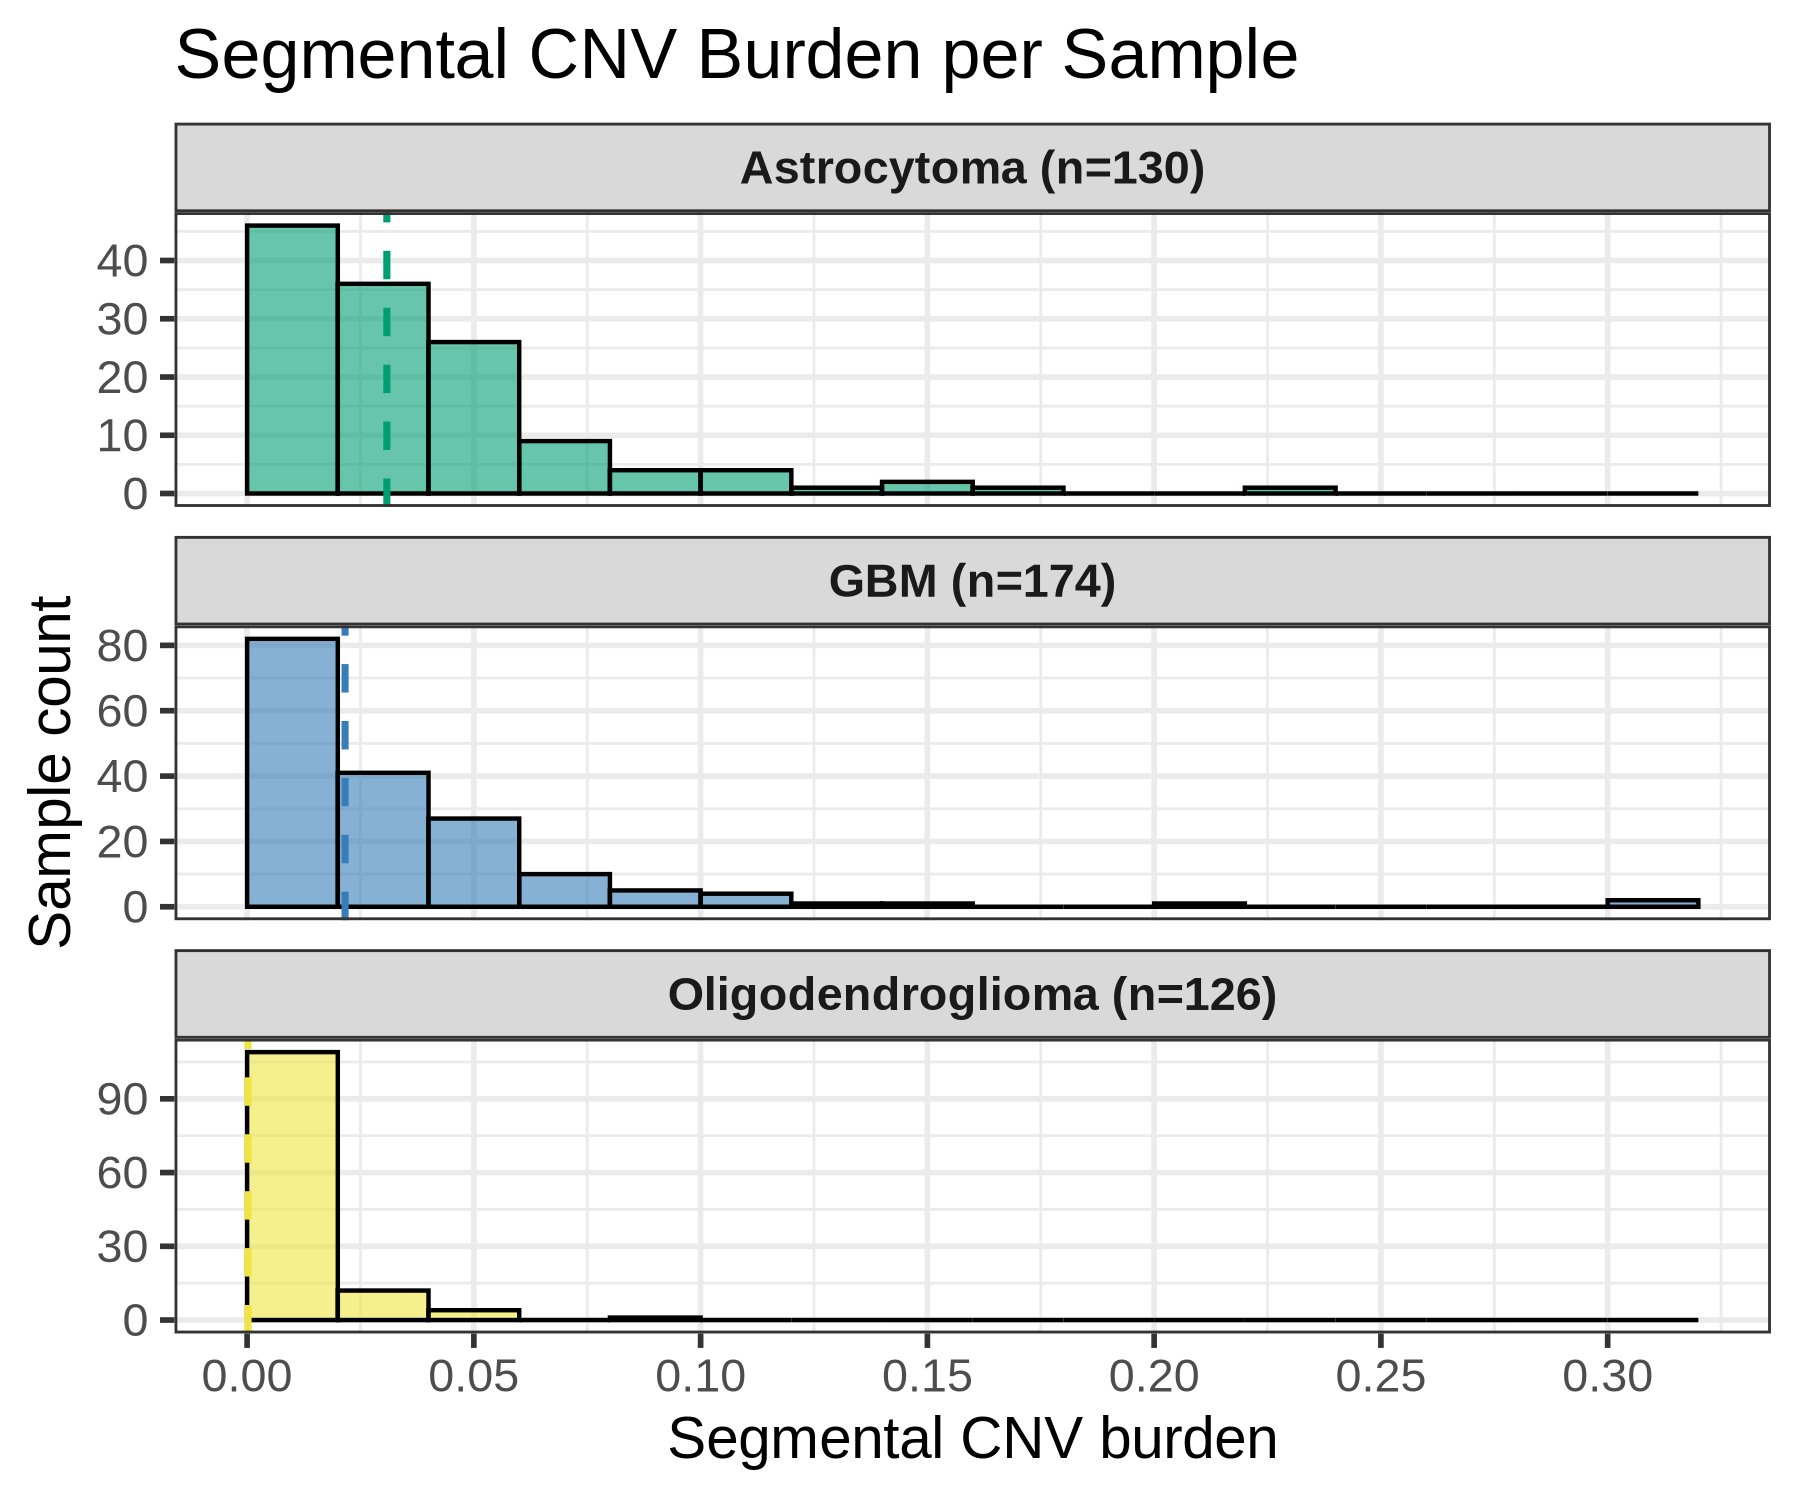

In [615]:

p_hist_burden

In [616]:
library(ggplot2)
library(dplyr)
library(ggpubr)   # for stat_cor

# Palette (same as before)
pal <- c(
  "Astrocytoma"       = "#009E73",
  "GBM"               = "#377EB8",
  "Oligodendroglioma" = "#F0E442"
)

dat_corr <- sample_scores %>%
  filter(!is.na(tumor_type),
         !is.na(segmental_bp),
         !is.na(segmental_cnv_burden)) %>%
  mutate(tumor_type = factor(tumor_type, levels = names(pal)))

# Facet labels with n
counts <- dat_corr %>% count(tumor_type, name = "n")
facet_labs <- setNames(
  paste0(levels(dat_corr$tumor_type),
         " (n=", counts$n[match(levels(dat_corr$tumor_type), counts$tumor_type)], ")"),
  levels(dat_corr$tumor_type)
)

In [617]:
p_corr <- ggplot(dat_corr, aes(x = segmental_bp, y = segmental_cnv_burden, color = tumor_type)) +
  geom_point(alpha = 0.7, size = 2) +
  geom_smooth(method = "lm", se = TRUE, linewidth = 0.8, show.legend = FALSE) +
  stat_cor(method = "pearson",
           label.x.npc = "left", label.y.npc = "top",
           size = 4, show.legend = FALSE) +
  scale_color_manual(values = pal) +
  # Show x in Mb
  scale_x_continuous(
    labels = function(x) x / 1e6  # raw bp -> Mb
  ) +
  facet_wrap(
    ~ tumor_type, ncol = 1, scales = "free_x",
    labeller = labeller(tumor_type = facet_labs)
  ) +
  labs(
    x = "Segmental CNV bases (Mb)",
    y = "Segmental CNV burden",
    title = "Correlation plot"
  ) +
  theme_bw(base_size = 4) +
  theme(
    legend.position = "none",
    strip.text = element_text(face = "bold")
  )


`geom_smooth()` using formula = 'y ~ x'


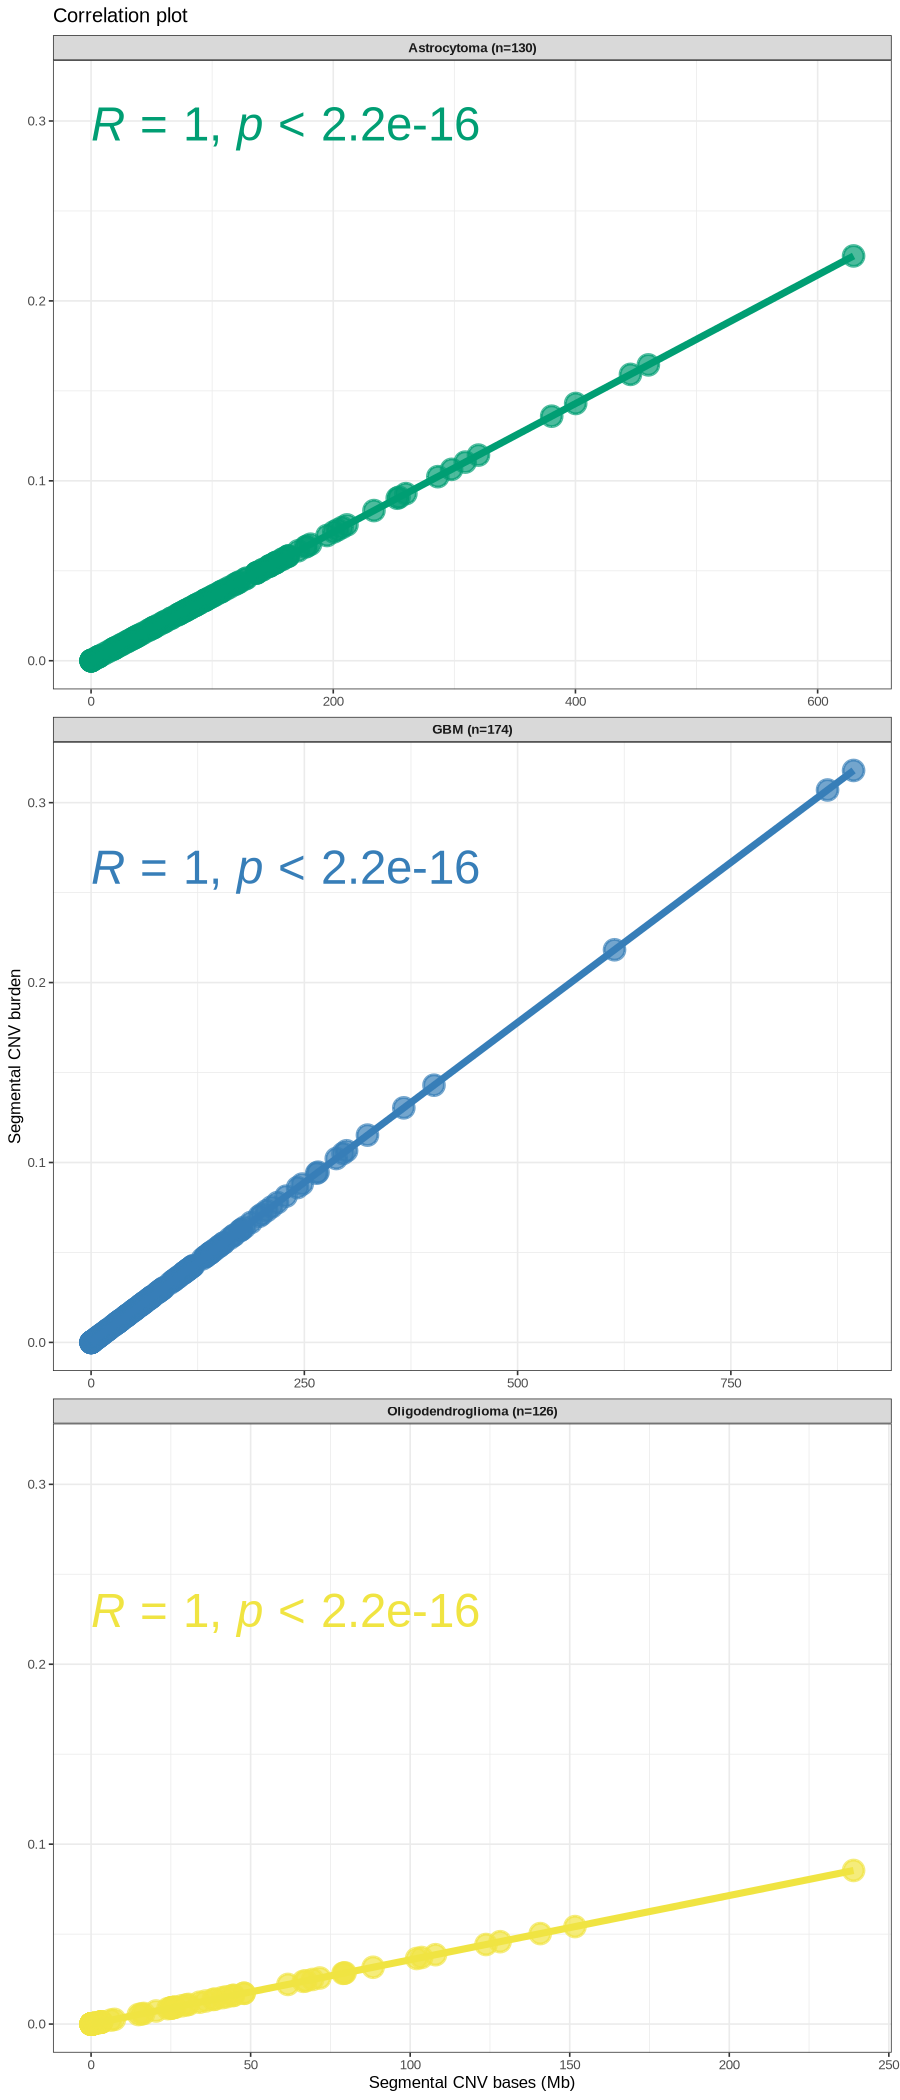

In [618]:
options(repr.plot.width = 3, repr.plot.height = 7, repr.plot.res = 300)
p_corr

In [619]:
head(cnv_with_arms_all)


,ID,chrom,loc.start,loc.end,num.mark,seg.mean,tumor_type,stage,sample,row_id,⋯,side,arm,arm_start,arm_end,arm_length,overlap_start,overlap_end,overlap_len,arm_fraction,cna_status
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TCGA-CS-4938-01,chr1,3218610,91104026,50505,0.0027,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_1,⋯,p,1p,0.00e+00,125000000,125000000,3218610,91104026,87885416,0.703083328,1
2,TCGA-CS-4938-01,chr1,91108204,91109793,2,-1.3703,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_2,⋯,p,1p,0.00e+00,125000000,125000000,91108204,91109793,1589,0.000012712,-1
3,TCGA-CS-4938-01,chr1,91112769,247813706,78501,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_3,⋯,p,1p,0.00e+00,125000000,125000000,91112769,125000000,33887231,0.271097848,1
4,TCGA-CS-4938-01,chr1,91112769,247813706,78501,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_3,⋯,q,1q,1.25e+08,249250621,124250621,125000000,247813706,122813706,0.988435350,1
5,TCGA-CS-4938-01,chr2,484222,106146307,55667,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_4,⋯,p,2p,0.00e+00,93300000,93300000,484222,93300000,92815778,0.994810054,1
6,TCGA-CS-4938-01,chr2,484222,106146307,55667,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_4,⋯,q,2q,9.33e+07,243199373,149899373,93300000,106146307,12846307,0.085699538,1


In [620]:
unique(cnv_with_arms_all$stage)

[1] "Primary"

In [621]:
library(dplyr)
library(tidyr)

# --------------------------
# PARAMETERS (tweak as needed)
# --------------------------
aneuploidy_threshold <- 0.80   # arm-level threshold (Taylor-like)
segmean_threshold    <- 0.25   # |seg.mean| to call a segment "altered" if cna_status is unreliable
prefer_cna_status    <- FALSE  # set TRUE if cna_status is trustworthy (nonzero = altered)

# --------------------------
# INPUT
# Use your full table that includes 'stage'
#   Required cols: ID, tumor_type, stage, arm, arm_length, overlap_len, seg.mean, (optional) cna_status
#   Each row is a segment–arm overlap with length 'overlap_len'
# --------------------------
df <- cnv_with_arms_all %>%
  mutate(
    arm_length = as.numeric(arm_length),
    overlap_len = as.numeric(overlap_len),
    seg.mean   = as.numeric(seg.mean),
    cna_status = suppressWarnings(as.numeric(cna_status)),
    # Normalize stage labels to exactly "Primary" / "Recurrence"
    stage = ifelse(grepl("prim", tolower(stage)), "Primary",
             ifelse(grepl("rec", tolower(stage)),  "Recurrence", stage))
  ) %>%
  filter(stage %in% c("Primary", "Recurrence")) %>%   # keep only desired stages
  mutate(
    is_altered = if (prefer_cna_status && any(!is.na(cna_status))) {
      cna_status != 0
    } else {
      abs(seg.mean) >= segmean_threshold
    }
  )

# --------------------------
# PER-ARM SUMMARY (per ID × stage × arm)
# --------------------------
arm_summary <- df %>%
  group_by(ID, tumor_type, stage, arm) %>%
  summarise(
    arm_length = max(arm_length, na.rm = TRUE),              # robust to 'first' issues
    altered_bp = sum(overlap_len[is_altered], na.rm = TRUE)
  , .groups = "drop") %>%
  mutate(
    altered_bp   = pmin(altered_bp, arm_length),             # cap at arm size
    frac_altered = ifelse(is.finite(arm_length) & arm_length > 0,
                          altered_bp / arm_length, NA_real_),
    is_aneuploid = frac_altered >= aneuploidy_threshold
  )

# --------------------------
# PER-SAMPLE × STAGE SCORES
#   1) n_aneuploid_arms
#   2) segmental_cnv_burden = altered bp on non-aneuploid arms / total arm bp
# --------------------------
sample_scores <- arm_summary %>%
  group_by(ID, tumor_type, stage) %>%
  summarise(
    n_aneuploid_arms     = sum(is_aneuploid, na.rm = TRUE),
    segmental_bp         = sum(altered_bp[!is_aneuploid], na.rm = TRUE),
    total_arm_bp         = sum(arm_length, na.rm = TRUE),
    segmental_cnv_burden = segmental_bp / total_arm_bp
  , .groups = "drop") %>%
  arrange(tumor_type, stage, ID)

# Peek
head(sample_scores)


ID,tumor_type,stage,n_aneuploid_arms,segmental_bp,total_arm_bp,segmental_cnv_burden
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
TCGA-CS-4938-01,Astrocytoma,Primary,1,136420978,2798633286,0.048745571
TCGA-CS-4942-01,Astrocytoma,Primary,2,114151701,2798633286,0.040788374
TCGA-CS-4943-01,Astrocytoma,Primary,4,254330672,2798633286,0.090876741
TCGA-CS-4944-01,Astrocytoma,Primary,1,66351435,2798633286,0.023708513
TCGA-CS-5393-01,Astrocytoma,Primary,1,109744742,2798633286,0.039213691
TCGA-CS-5394-01,Astrocytoma,Primary,1,23686426,2798633286,0.008463569


In [641]:
library(ggplot2)
library(ggforce)
library(ggpubr)
library(dplyr)

# Palette (same as before)
pal <- c(
  "Astrocytoma"       = "#009E73",
  "GBM"               = "#377EB8",
  "Oligodendroglioma" = "#F0E442"
)

# Data
dat_stage <- sample_scores %>%
  filter(!is.na(tumor_type), !is.na(stage), !is.na(n_aneuploid_arms)) %>%
  mutate(
    tumor_type = factor(tumor_type, levels = names(pal)),
    stage = factor(stage, levels = c("Primary","Recurrence"))
  )

# facet labels with n per tumor_type
counts_tt <- dat_stage %>% count(tumor_type, name = "n")
facet_labs <- setNames(
  paste0(levels(dat_stage$tumor_type),
         " (n=", counts_tt$n[match(levels(dat_stage$tumor_type), counts_tt$tumor_type)], ")"),
  levels(dat_stage$tumor_type)
)

# Pairwise stats (Wilcoxon) within each tumor_type
cmp <- compare_means(
  n_aneuploid_arms ~ stage,
  data = dat_stage,
  group.by = "tumor_type",
  method = "wilcox.test",
  #p.adjust.method = "BH",
  comparisons = list(c("Primary","Recurrence"))
)

# Place the bracket a bit above the max per facet
ypos <- dat_stage %>%
  group_by(tumor_type) %>%
  summarise(y.position = max(n_aneuploid_arms, na.rm = TRUE) * 1.08, .groups = "drop")

cmp_plot <- cmp %>%
  left_join(ypos, by = "tumor_type") %>%
  filter(!is.na(p))  # drop facets without both stages

# Plot
p_stage <- ggplot(dat_stage, aes(x = stage, y = n_aneuploid_arms,
                                 fill = tumor_type, color = tumor_type)) +
  geom_violin(alpha = 0.3, trim = FALSE, width = 0.9) +
  ggforce::geom_sina(alpha = 0.9, size = 2, maxwidth = 0.8) +
  geom_boxplot(fill = "white", width = 0.25, outlier.shape = NA) +
  scale_fill_manual(values = pal) +
  scale_color_manual(values = pal) +
  facet_wrap(~ tumor_type, ncol = 1, scales = "free_y",
             labeller = labeller(tumor_type = facet_labs)) +
  stat_pvalue_manual(
    cmp_plot,
    label = "p.signif", y.position = "y.position",
    xmin = "group1", xmax = "group2",
    bracket.size = 0.6, tip.length = 0.01, size = 4
  ) +
  labs(
    x = NULL,
    y = "Number of aneuploid arms",
    title = "Aneuploid Arms by Stage (faceted by Tumor Type)"
  ) +
  theme_bw(base_size = 14) +
  theme(
    legend.position = "none",
    strip.text = element_text(face = "bold")
  )

Warning message:
“Unknown or uninitialised column: `p`.”


ERROR: Error in (function (x, cutpoints = c(0.3, 0.6, 0.8, 0.9, 0.95), symbols = if (numeric.x) c(" ", : argument "x" is missing, with no default


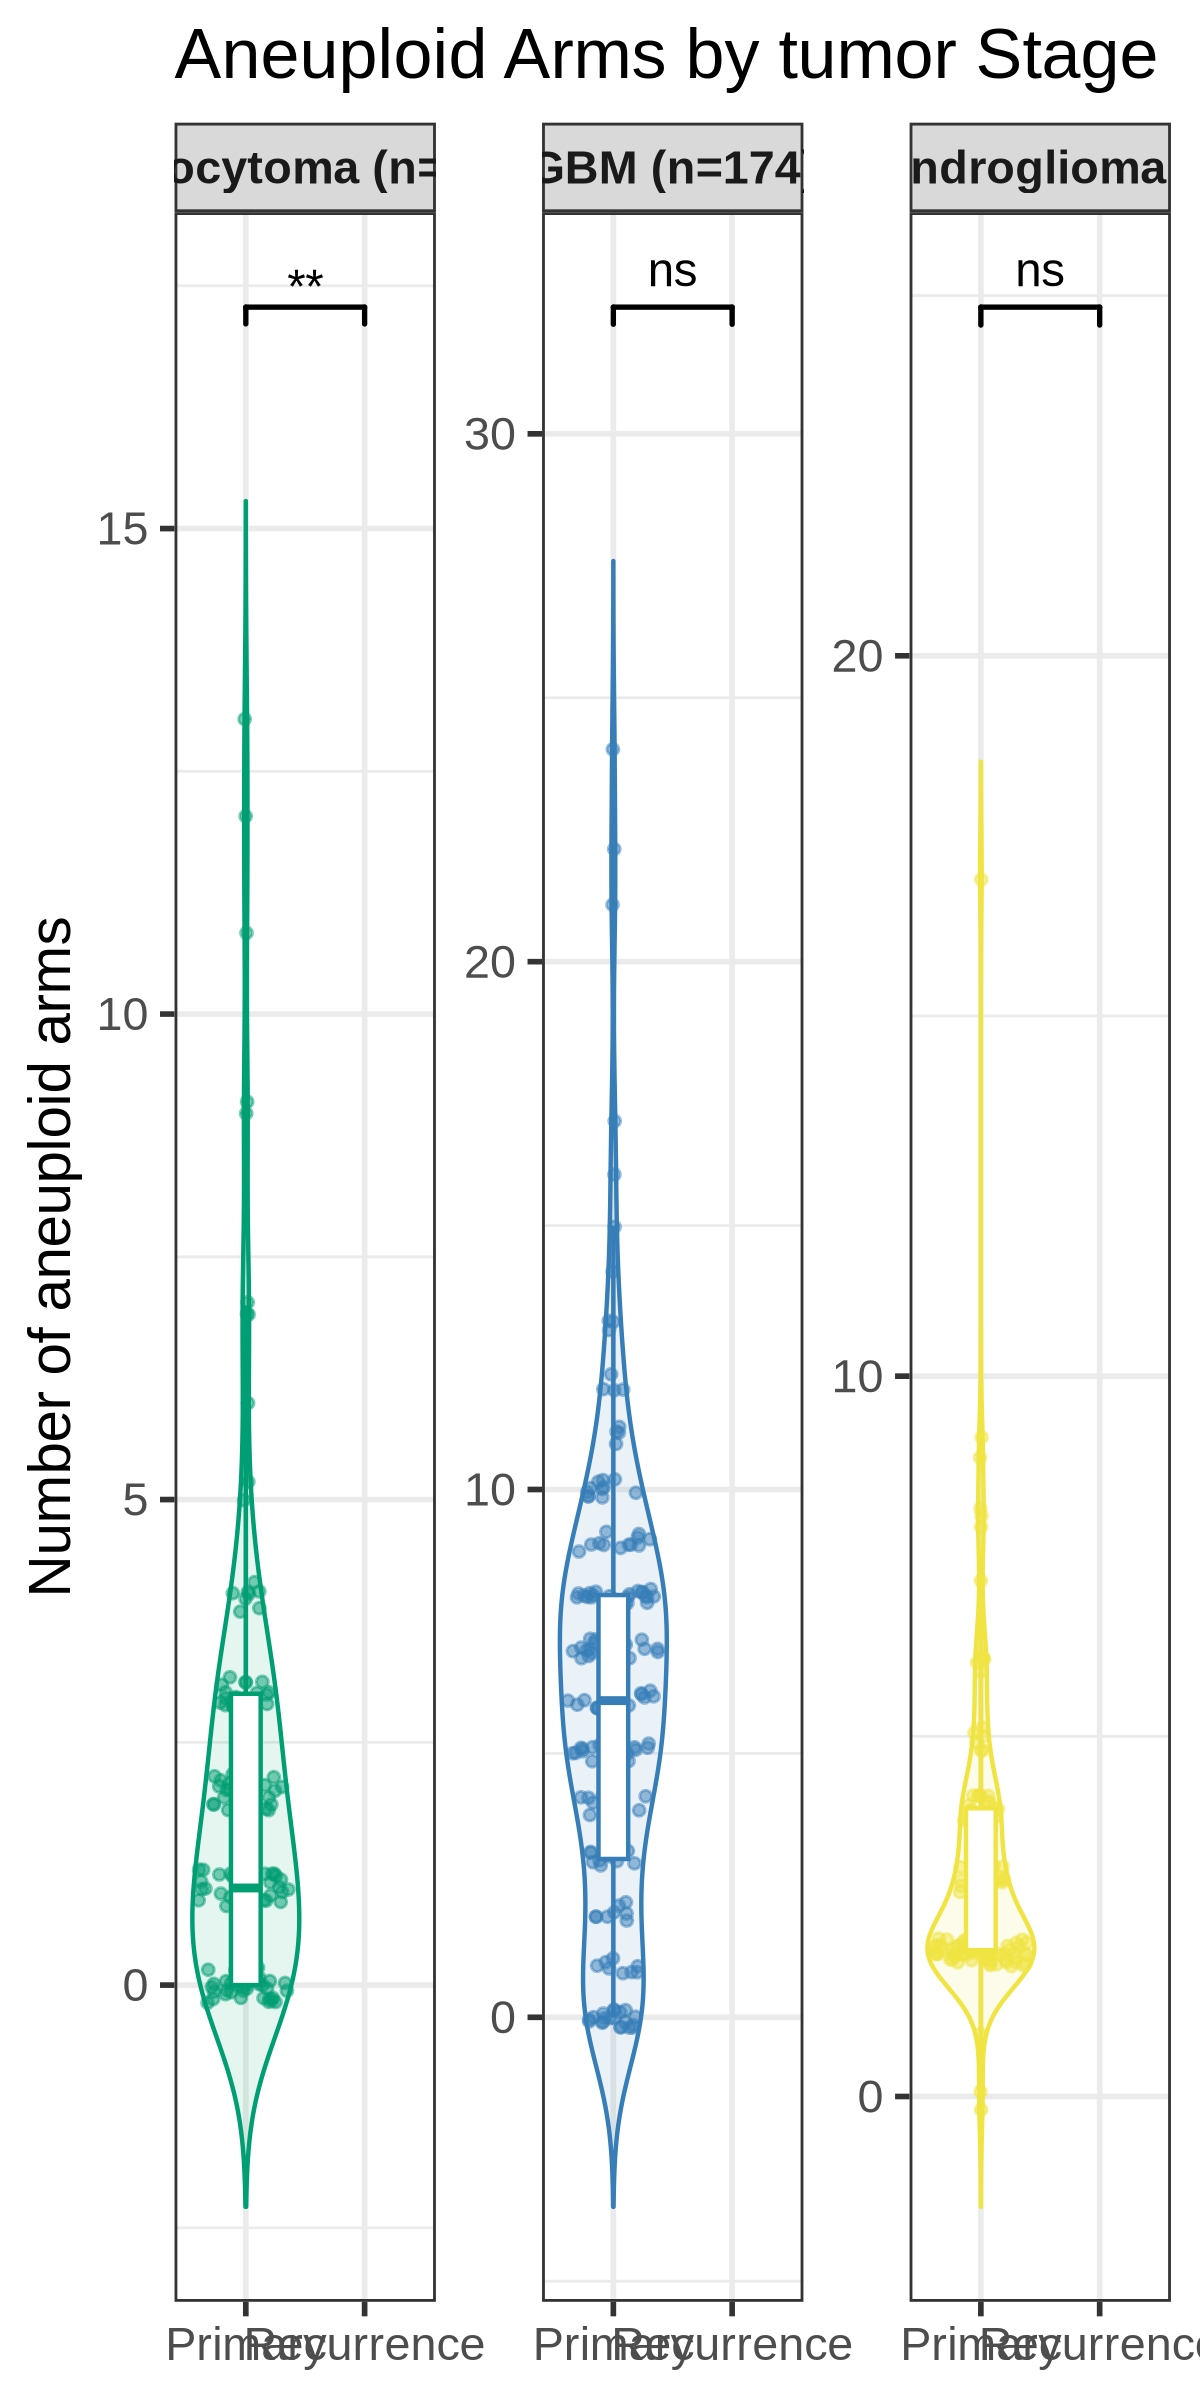

In [642]:
options(repr.plot.width = 4, repr.plot.height = 8, repr.plot.res = 300)

p_stage

In [624]:
options(repr.plot.width = 8, repr.plot.height = 4, repr.plot.res = 300)


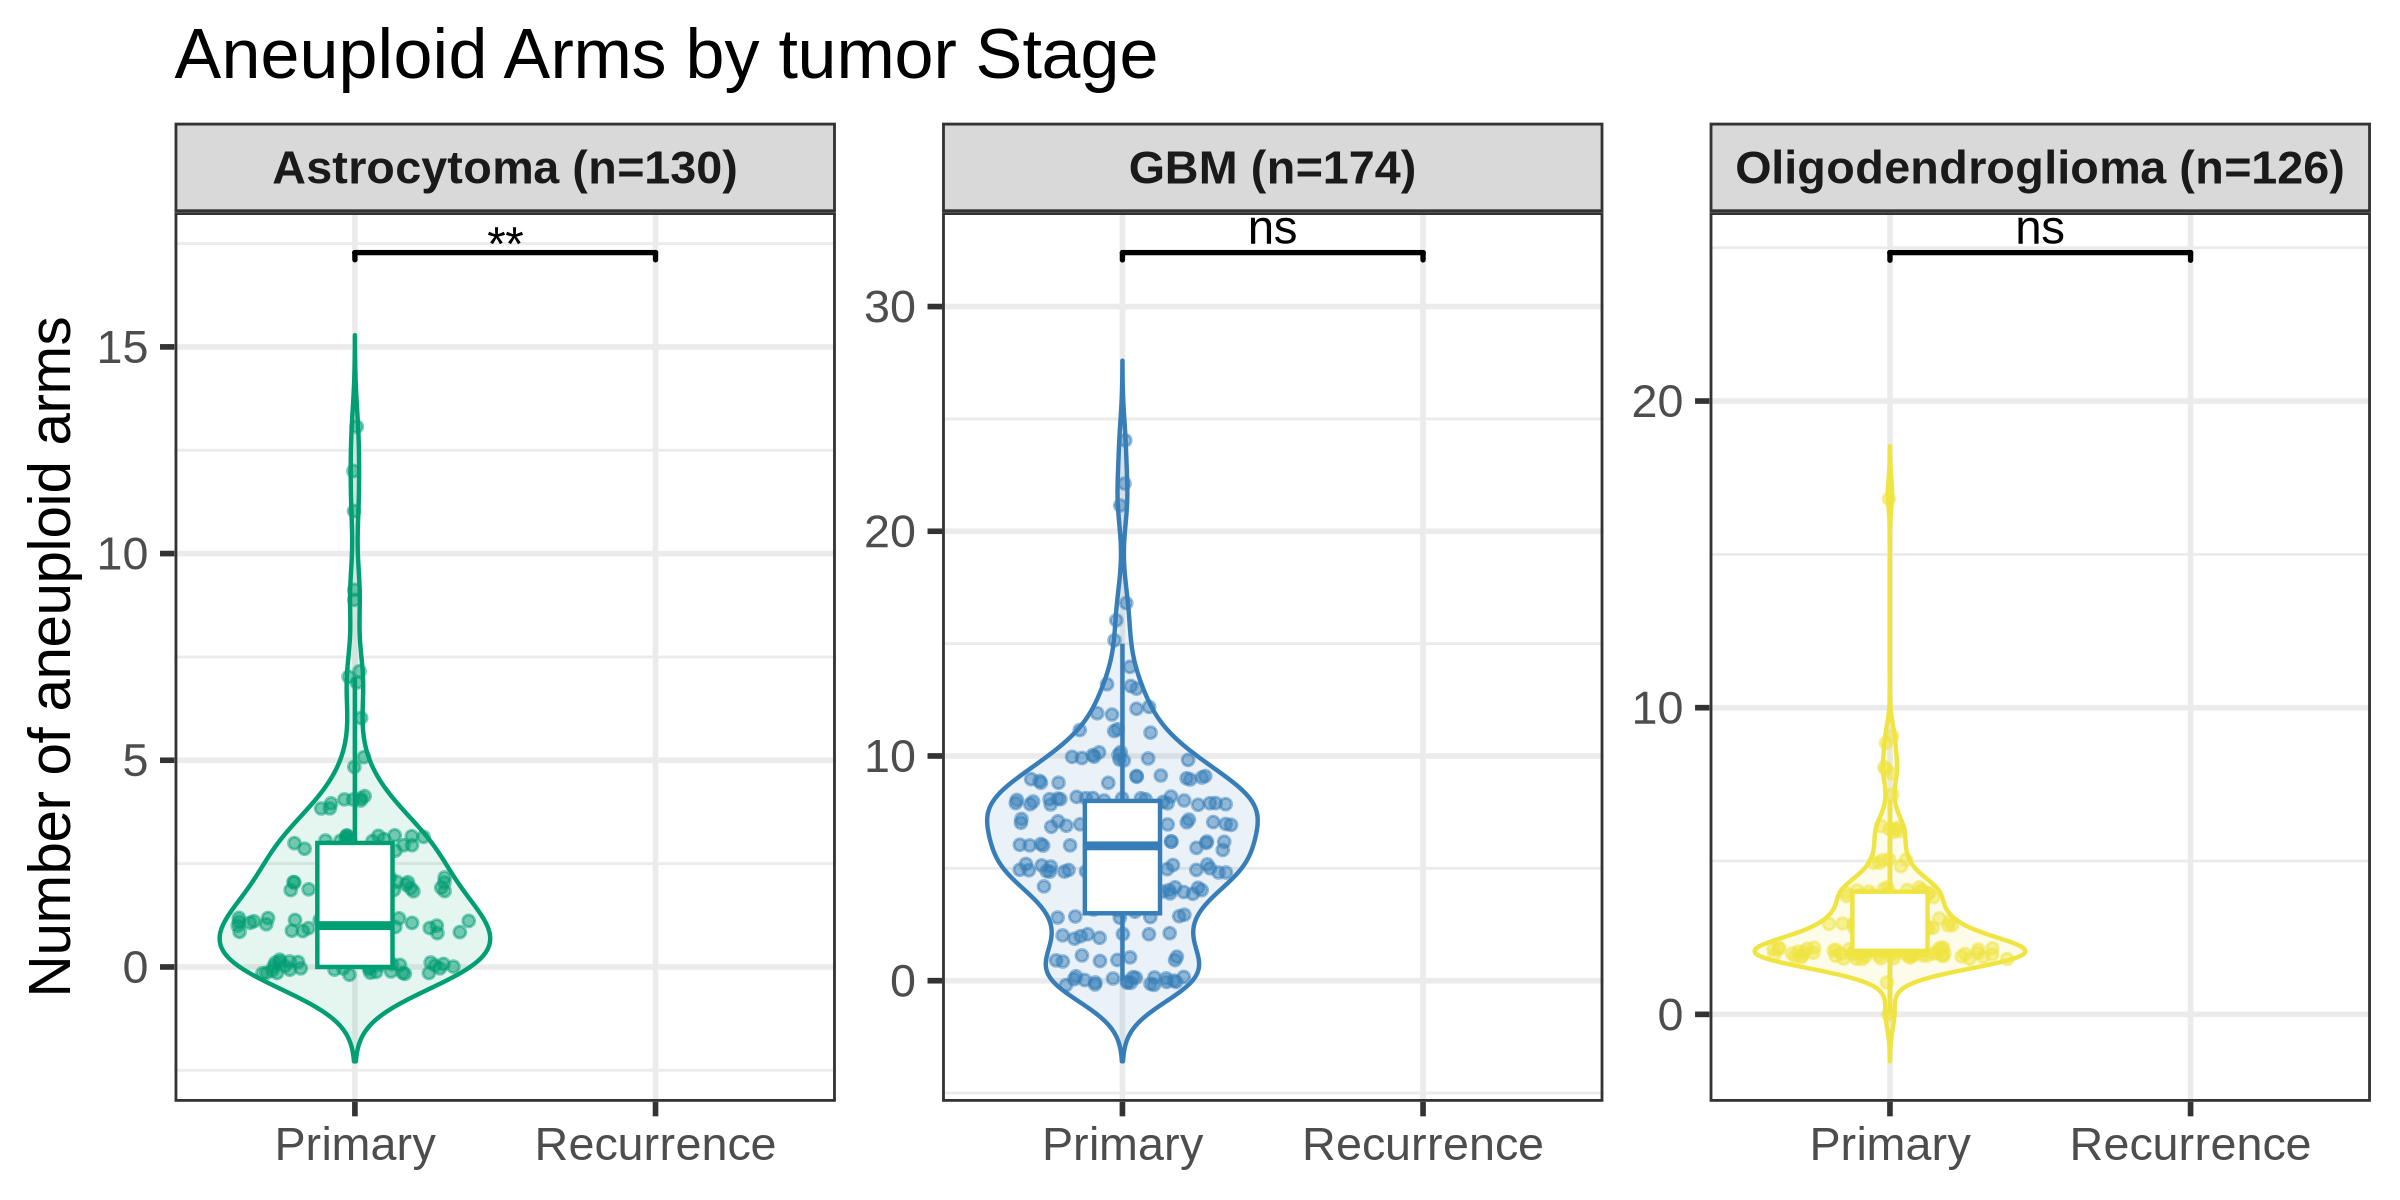

In [625]:
# ... keep your libraries, pal, dat_stage, facet labels, and cmp_plot objects as before ...

p_stage <- ggplot(dat_stage, aes(x = stage, y = n_aneuploid_arms,
                                 fill = tumor_type, color = tumor_type)) +
  # color mapped by stage
  geom_violin(aes(alpha = stage), trim = FALSE, width = 0.9) +
  ggforce::geom_sina(alpha = 0.5, size = 1, maxwidth = 0.8) +
  geom_boxplot(fill = "white", width = 0.25, outlier.shape = NA) +
  stat_pvalue_manual(
    cmp_plot,
    label = "p.signif",  y.position = "y.position",
    xmin = "group1", xmax = "group2",
    bracket.size = 0.6, tip.length = 0.01, size = 4
  ) +
  scale_fill_manual(values = pal) +
  scale_color_manual(values = pal) +
  scale_alpha_manual(values = c(Primary = 0.1, Recurrence = 0.6), guide = "none") +
  #facet_wrap(~ tumor_type, ncol = 1, scales = "free_y", # 3 rows single colum
             facet_wrap(~ tumor_type, nrow = 1, scales = "free_y", # single row
             labeller = labeller(tumor_type = facet_labs)) +
  labs(
    x = NULL,
    y = "Number of aneuploid arms",
    title = "Aneuploid Arms by tumor Stage"
  ) +
  theme_bw(base_size = 14) +
  theme(
    legend.position = "none",
    strip.text = element_text(face = "bold")
  )

p_stage


In [626]:
#ggsave("/home/mjehangir/telomere-sv-analysis/plots/TCGA_plots/aneuploidy_arm_by_stage.pdf", p_stage, width = 8, height = 4)

In [627]:
head(dat_stage)

ID,tumor_type,stage,n_aneuploid_arms,segmental_bp,total_arm_bp,segmental_cnv_burden
<chr>,<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>
TCGA-CS-4938-01,Astrocytoma,Primary,1,136420978,2798633286,0.048745571
TCGA-CS-4942-01,Astrocytoma,Primary,2,114151701,2798633286,0.040788374
TCGA-CS-4943-01,Astrocytoma,Primary,4,254330672,2798633286,0.090876741
TCGA-CS-4944-01,Astrocytoma,Primary,1,66351435,2798633286,0.023708513
TCGA-CS-5393-01,Astrocytoma,Primary,1,109744742,2798633286,0.039213691
TCGA-CS-5394-01,Astrocytoma,Primary,1,23686426,2798633286,0.008463569


In [628]:
#dat_stage %>%
#  filter(grepl("02", ID))


In [629]:
######based on BH wilcoxin test#######
library(ggplot2)
library(ggforce)
library(ggpubr)
library(dplyr)

# Palette (same as before)
pal <- c(
  "Astrocytoma"       = "#009E73",
  "GBM"               = "#377EB8",
  "Oligodendroglioma" = "#F0E442"
)

# Data
dat_stage_burden <- sample_scores %>%
  filter(!is.na(tumor_type), !is.na(stage), !is.na(segmental_cnv_burden)) %>%
  mutate(
    tumor_type = factor(tumor_type, levels = names(pal)),
    stage = factor(stage, levels = c("Primary","Recurrence"))
  )


# Facet labels with n per tumor_type
counts_tt2 <- dat_stage_burden %>% count(tumor_type, name = "n")
facet_labs2 <- setNames(
  paste0(levels(dat_stage_burden$tumor_type),
         " (n=", counts_tt2$n[match(levels(dat_stage_burden$tumor_type), counts_tt2$tumor_type)], ")"),
  levels(dat_stage_burden$tumor_type)
)

cmp2 <- compare_means(
  segmental_cnv_burden ~ stage,
  data = dat_stage_burden,
  group.by = "tumor_type",
  method = "wilcox.test",
  paired = TRUE,                      # ✅ key change
  p.adjust.method = "BH",
  comparisons = list(c("Primary","Recurrence"))
)

# y-positions for p-value brackets
ypos2 <- dat_stage_burden %>%
  group_by(tumor_type) %>%
  summarise(y.position = max(segmental_cnv_burden, na.rm = TRUE) * 1.08, .groups = "drop")

cmp_plot2 <- cmp2 %>%
  left_join(ypos2, by = "tumor_type") %>%
  filter(!is.na(p))

# Plot
p_stage_burden <- ggplot(dat_stage_burden,
                         aes(x = stage, y = segmental_cnv_burden,
                             fill = tumor_type, color = tumor_type)) +
  geom_violin(aes(alpha = stage), trim = FALSE, width = 0.9) +
  ggforce::geom_sina(alpha = 0.5, size = 1, maxwidth = 0.8) +
  geom_boxplot(fill = "white", width = 0.25, outlier.shape = NA) +
  stat_pvalue_manual(
    cmp_plot2,
    label = "p.signif", y.position = "y.position",
    xmin = "group1", xmax = "group2",
    bracket.size = 0.6, tip.length = 0.01, size = 4
  ) +
  scale_fill_manual(values = pal) +
  scale_color_manual(values = pal) +
  scale_alpha_manual(values = c(Primary = 0.1, Recurrence = 0.6), guide = "none") +
  facet_wrap(~ tumor_type, nrow = 1, scales = "free_y",
             labeller = labeller(tumor_type = facet_labs2)) +
  labs(
    x = NULL,
    y = "Segmental CNV burden",
    title = "Segmental CNV Burden by Stage"
  ) +
  theme_bw(base_size = 14) +
  theme(
    legend.position = "none",
    strip.text = element_text(face = "bold")
  )

Warning message:
“Unknown or uninitialised column: `p`.”


ERROR: Error in (function (x, cutpoints = c(0.3, 0.6, 0.8, 0.9, 0.95), symbols = if (numeric.x) c(" ", : argument "x" is missing, with no default


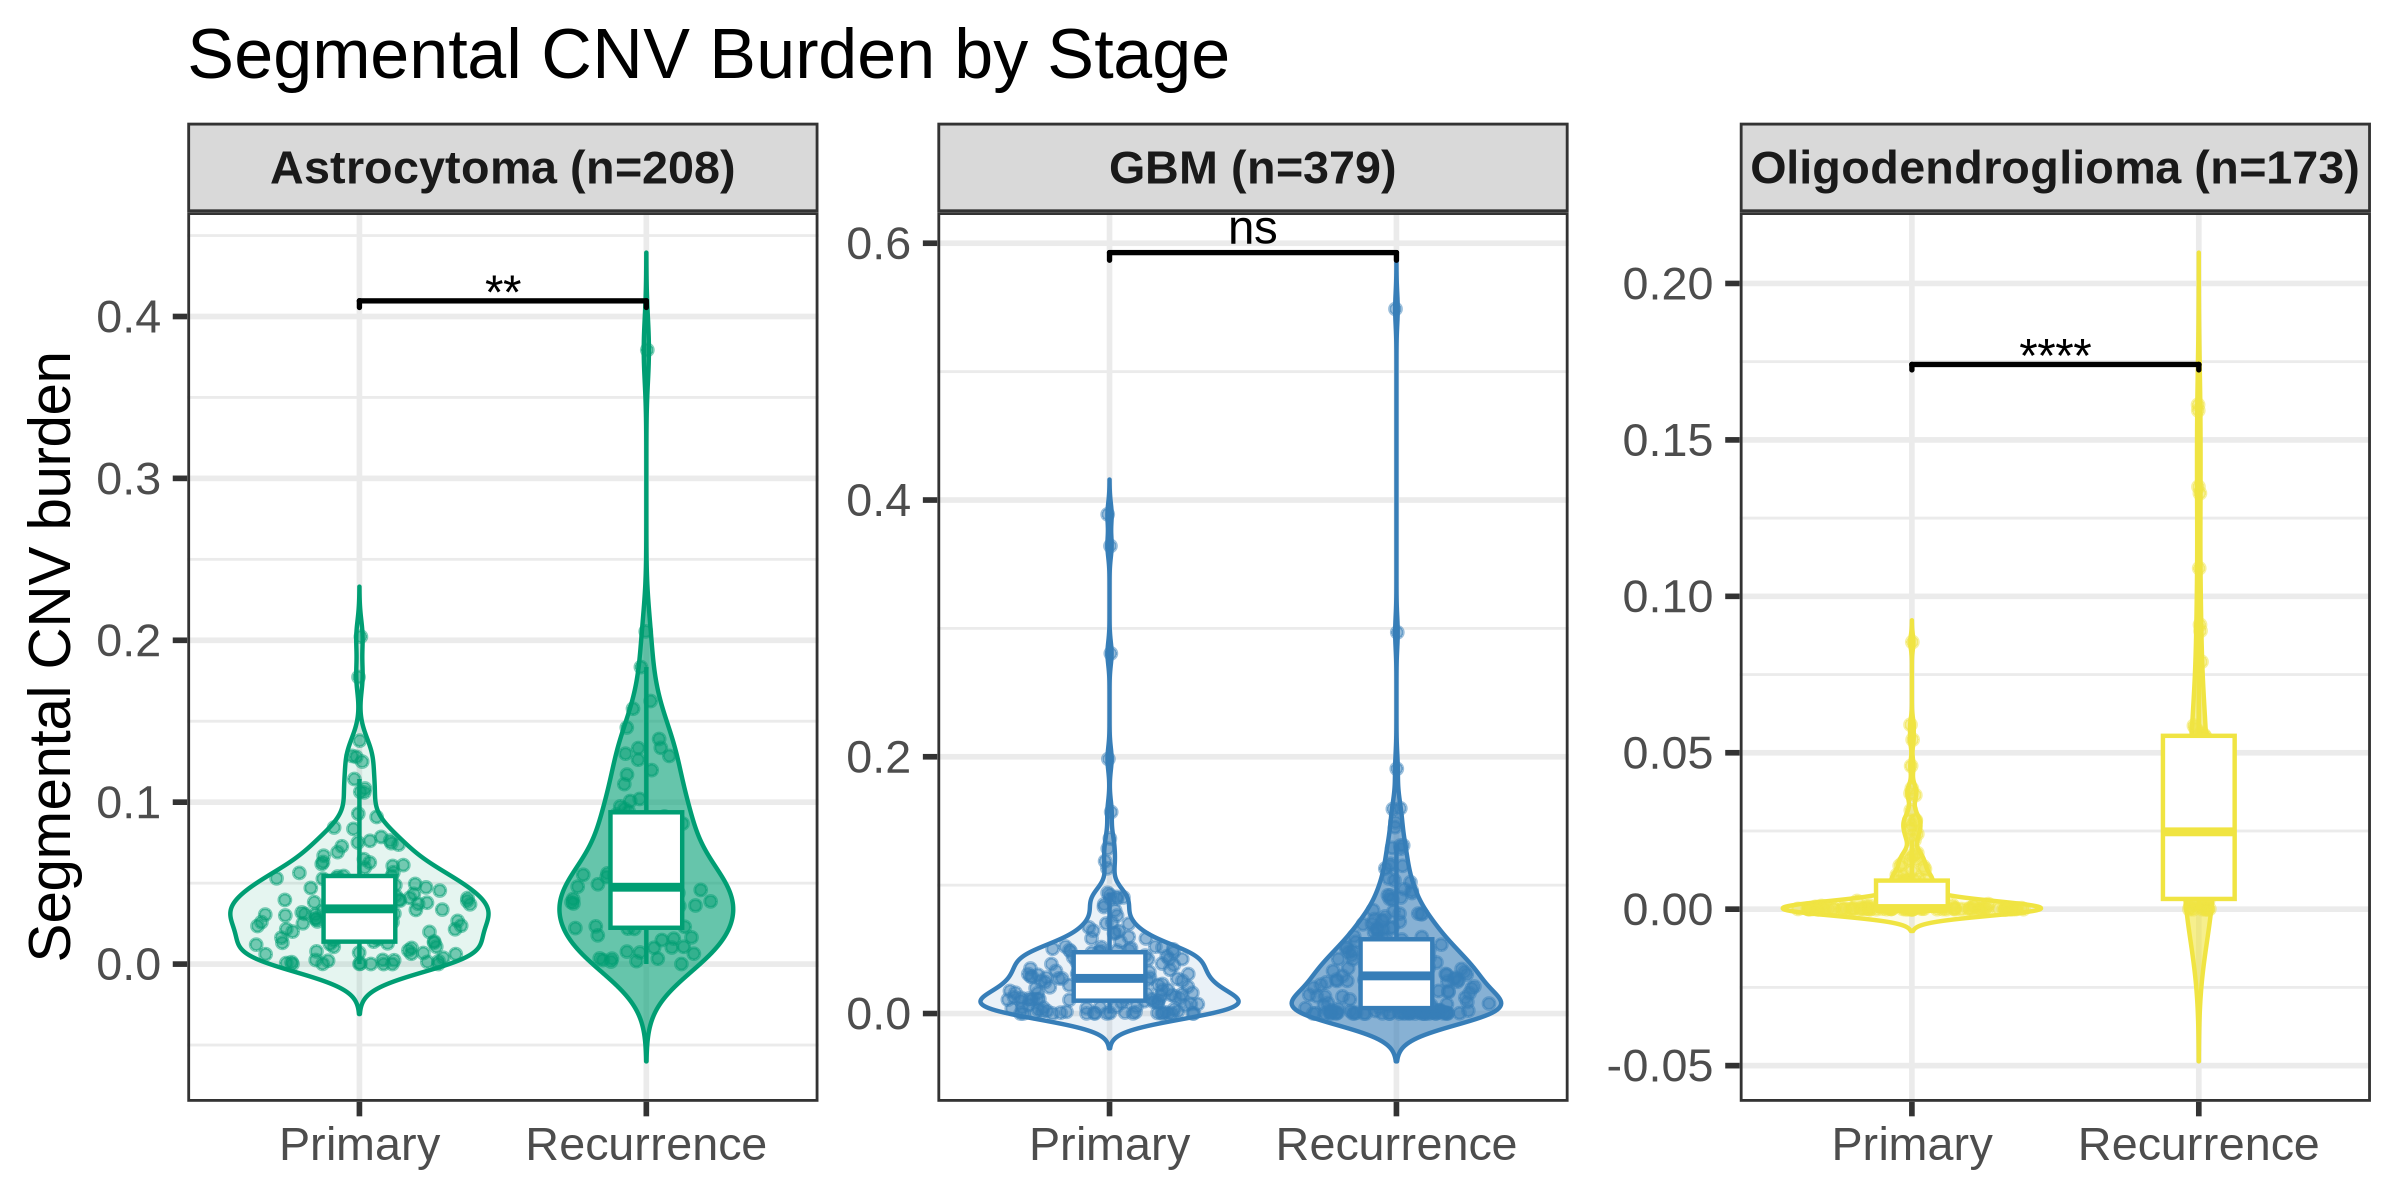

In [631]:
p_stage_burden

In [550]:
#ggsave("/home/mjehangir/telomere-sv-analysis/plots/TCGA_plots/segmental_CNVs_by_stage.pdf", p_stage_burden, width = 8, height = 4)

In [551]:
ggsave("/home/mjehangir/telomere-sv-analysis/plots/TCGA_plots/segmental_CNVs_by_stage.pdf", p_stage_burden, width = 8, height = 4)

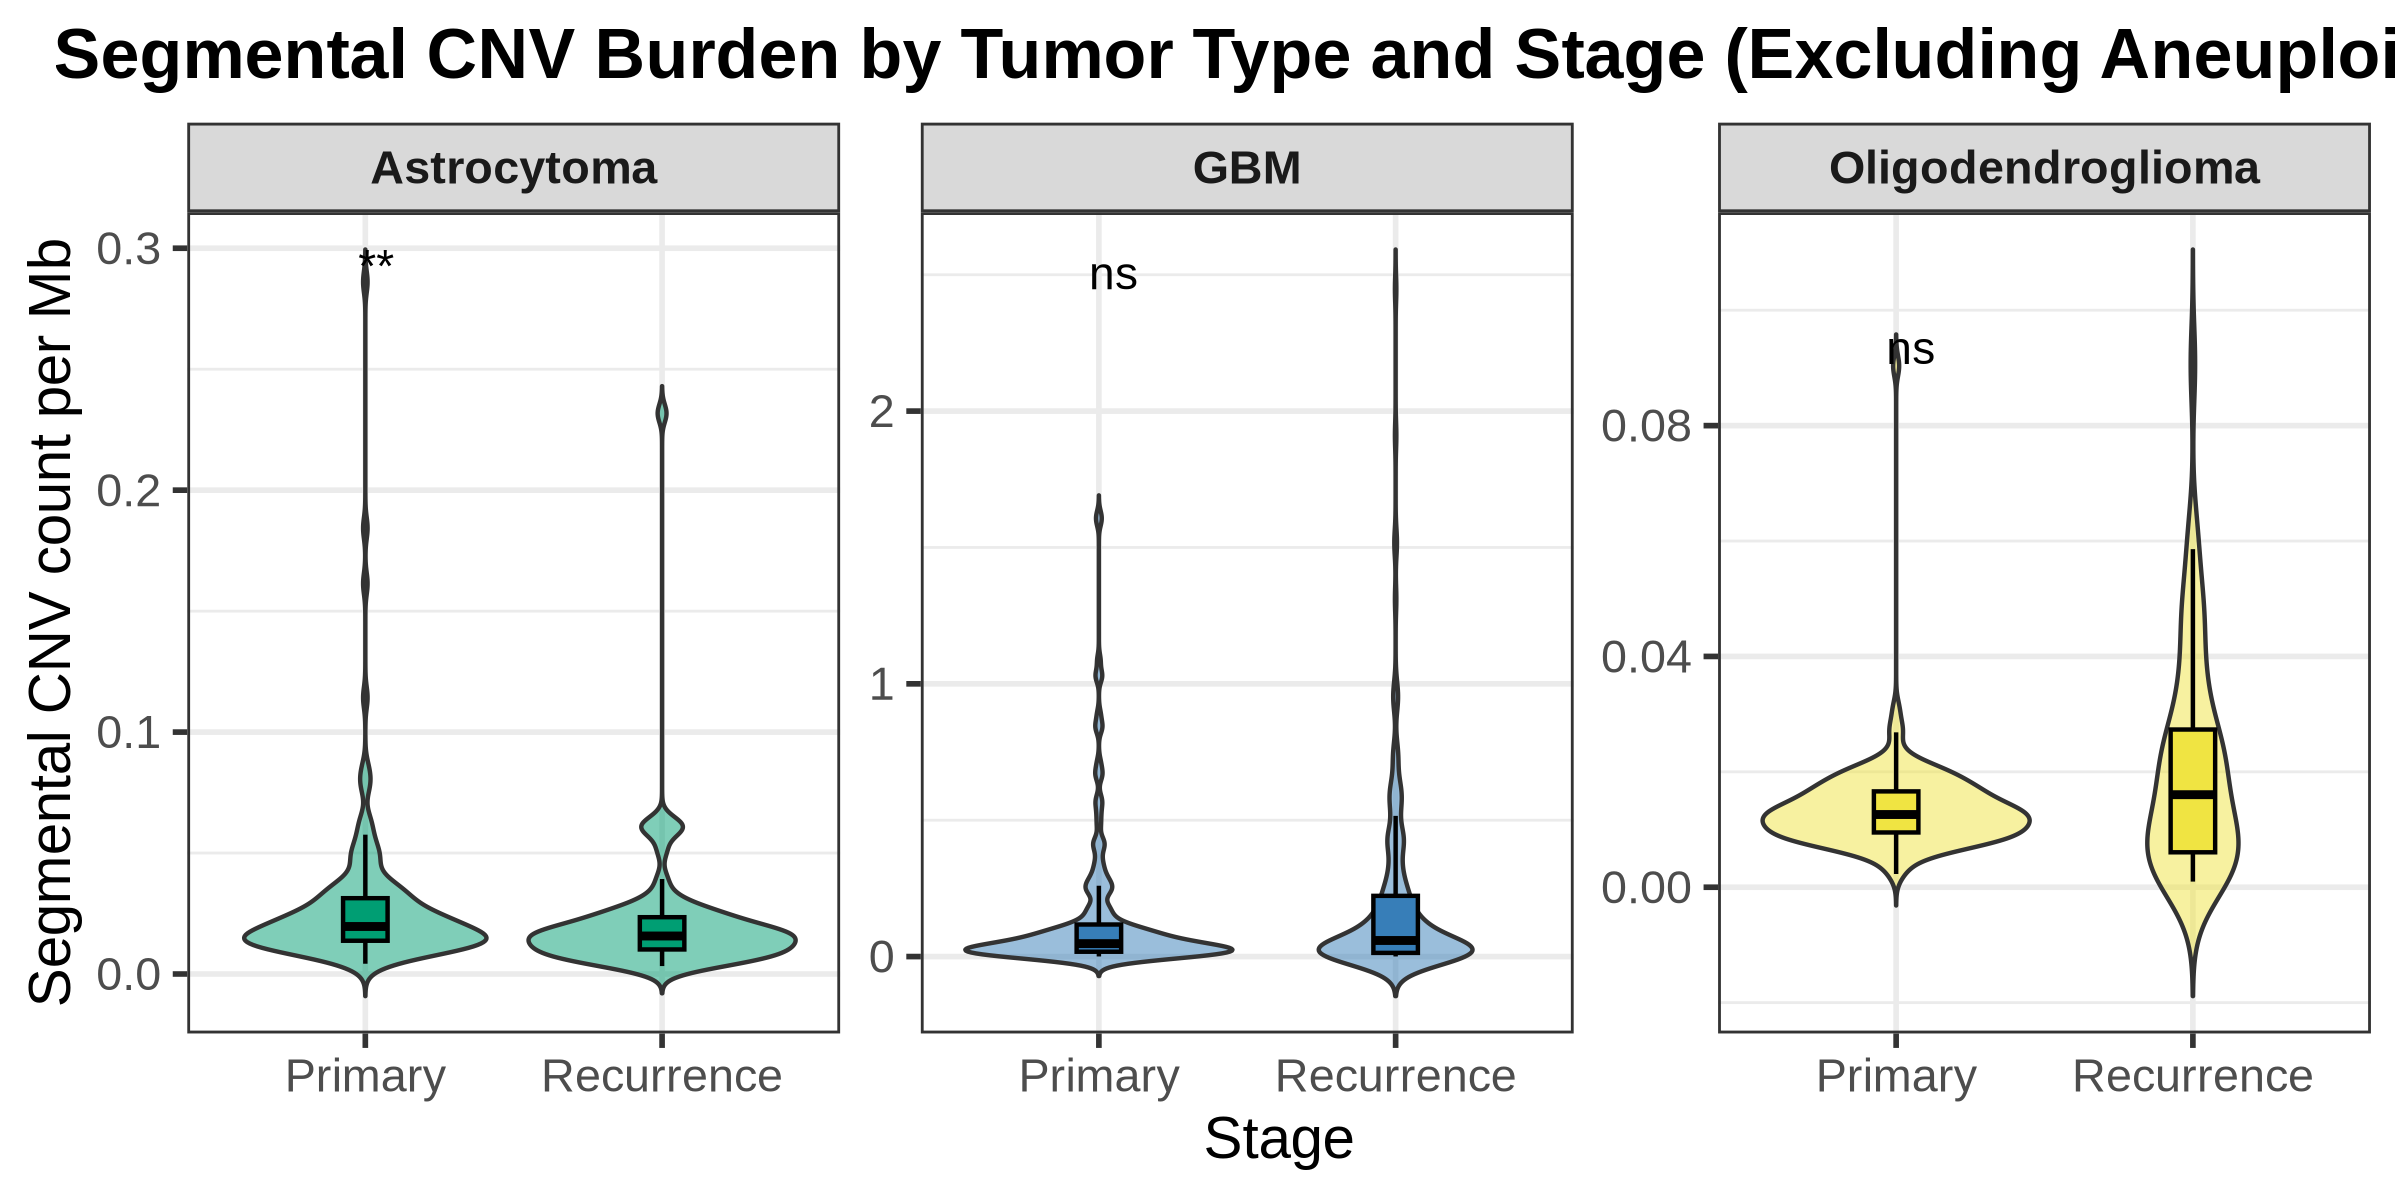

In [552]:
# ===============================
# 📚 Load libraries
# ===============================
library(dplyr)
library(ggplot2)
library(ggpubr)

# ===============================
# ⚙️ Parameters
# ===============================
genome_size <- 3055000000    # CHM13v2 genome size in bp
genome_size_mb <- genome_size / 1e6
min_cnv_size <- 1000          # Minimum CNV size (bp) to keep
arm_fraction_cutoff <- 0.8       # Max arm fraction for segmental CNVs

# ===============================
# 🧬 Filter CNV data
# ===============================
segmental_cnv <- cnv_with_arms_all %>%
  mutate(cnv_size = loc.end - loc.start) %>%
  filter(
    arm_fraction < arm_fraction_cutoff,  # exclude arm-level/aneuploidy
    cnv_size >= min_cnv_size,            # exclude very small CNVs
    !is.na(stage),
    !is.na(tumor_type)
  )

# ===============================
# 🧮 Calculate CNV counts per Mb per sample/stage
# ===============================
segmental_cnv_burden <- segmental_cnv %>%
  group_by(sample, tumor_type, stage) %>%
  summarise(
    segmental_cnv_count = n(),
    segmental_cnv_per_mb = segmental_cnv_count / genome_size_mb,
    .groups = "drop"
  )

# ===============================
# 🎨 Define color palette
# ===============================
pal <- c(
  "Astrocytoma"       = "#009E73",
  "GBM"               = "#377EB8",
  "Oligodendroglioma" = "#F0E442"
)

# ===============================
# 📊 Plot segmental CNV burden by stage
# ===============================
ggplot(segmental_cnv_burden, aes(x = stage, y = segmental_cnv_per_mb, fill = tumor_type)) +
  geom_violin(trim = FALSE, alpha = 0.5) +
  geom_boxplot(width = 0.15, outlier.shape = NA, color = "black") +
  stat_compare_means(
    aes(group = stage),
    method = "wilcox.test",
    label = "p.signif"
  ) +
  facet_wrap(~ tumor_type, scales = "free_y") +
  scale_fill_manual(values = pal) +
  labs(
    x = "Stage",
    y = "Segmental CNV count per Mb",
    title = "Segmental CNV Burden by Tumor Type and Stage (Excluding Aneuploidy)"
  ) +
  theme_bw(base_size = 14) +
  theme(
    legend.position = "none",
    strip.text = element_text(face = "bold"),
    plot.title = element_text(hjust = 0.5, face = "bold")
  )


In [214]:
unique(dat_stage_burden$stage)

[1] Primary    Recurrence
Levels: Primary Recurrence

In [215]:
head(dat_stage_burden)

ID,tumor_type,stage,n_aneuploid_arms,segmental_bp,total_arm_bp,segmental_cnv_burden
<chr>,<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>
TCGA-CS-4938-01,Astrocytoma,Primary,1,136420978,2798633286,0.048745571
TCGA-CS-4942-01,Astrocytoma,Primary,2,114151701,2798633286,0.040788374
TCGA-CS-4943-01,Astrocytoma,Primary,4,255677465,2798633286,0.091357973
TCGA-CS-4944-01,Astrocytoma,Primary,1,66351435,2798633286,0.023708513
TCGA-CS-5393-01,Astrocytoma,Primary,1,109744742,2798633286,0.039213691
TCGA-CS-5394-01,Astrocytoma,Primary,1,23686426,2798633286,0.008463569


# A tibble: 3 × 2
  tumor_type        n_paired_patients
  <fct>                         <int>
1 Astrocytoma                       2
2 GBM                             163
3 Oligodendroglioma                 3


Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


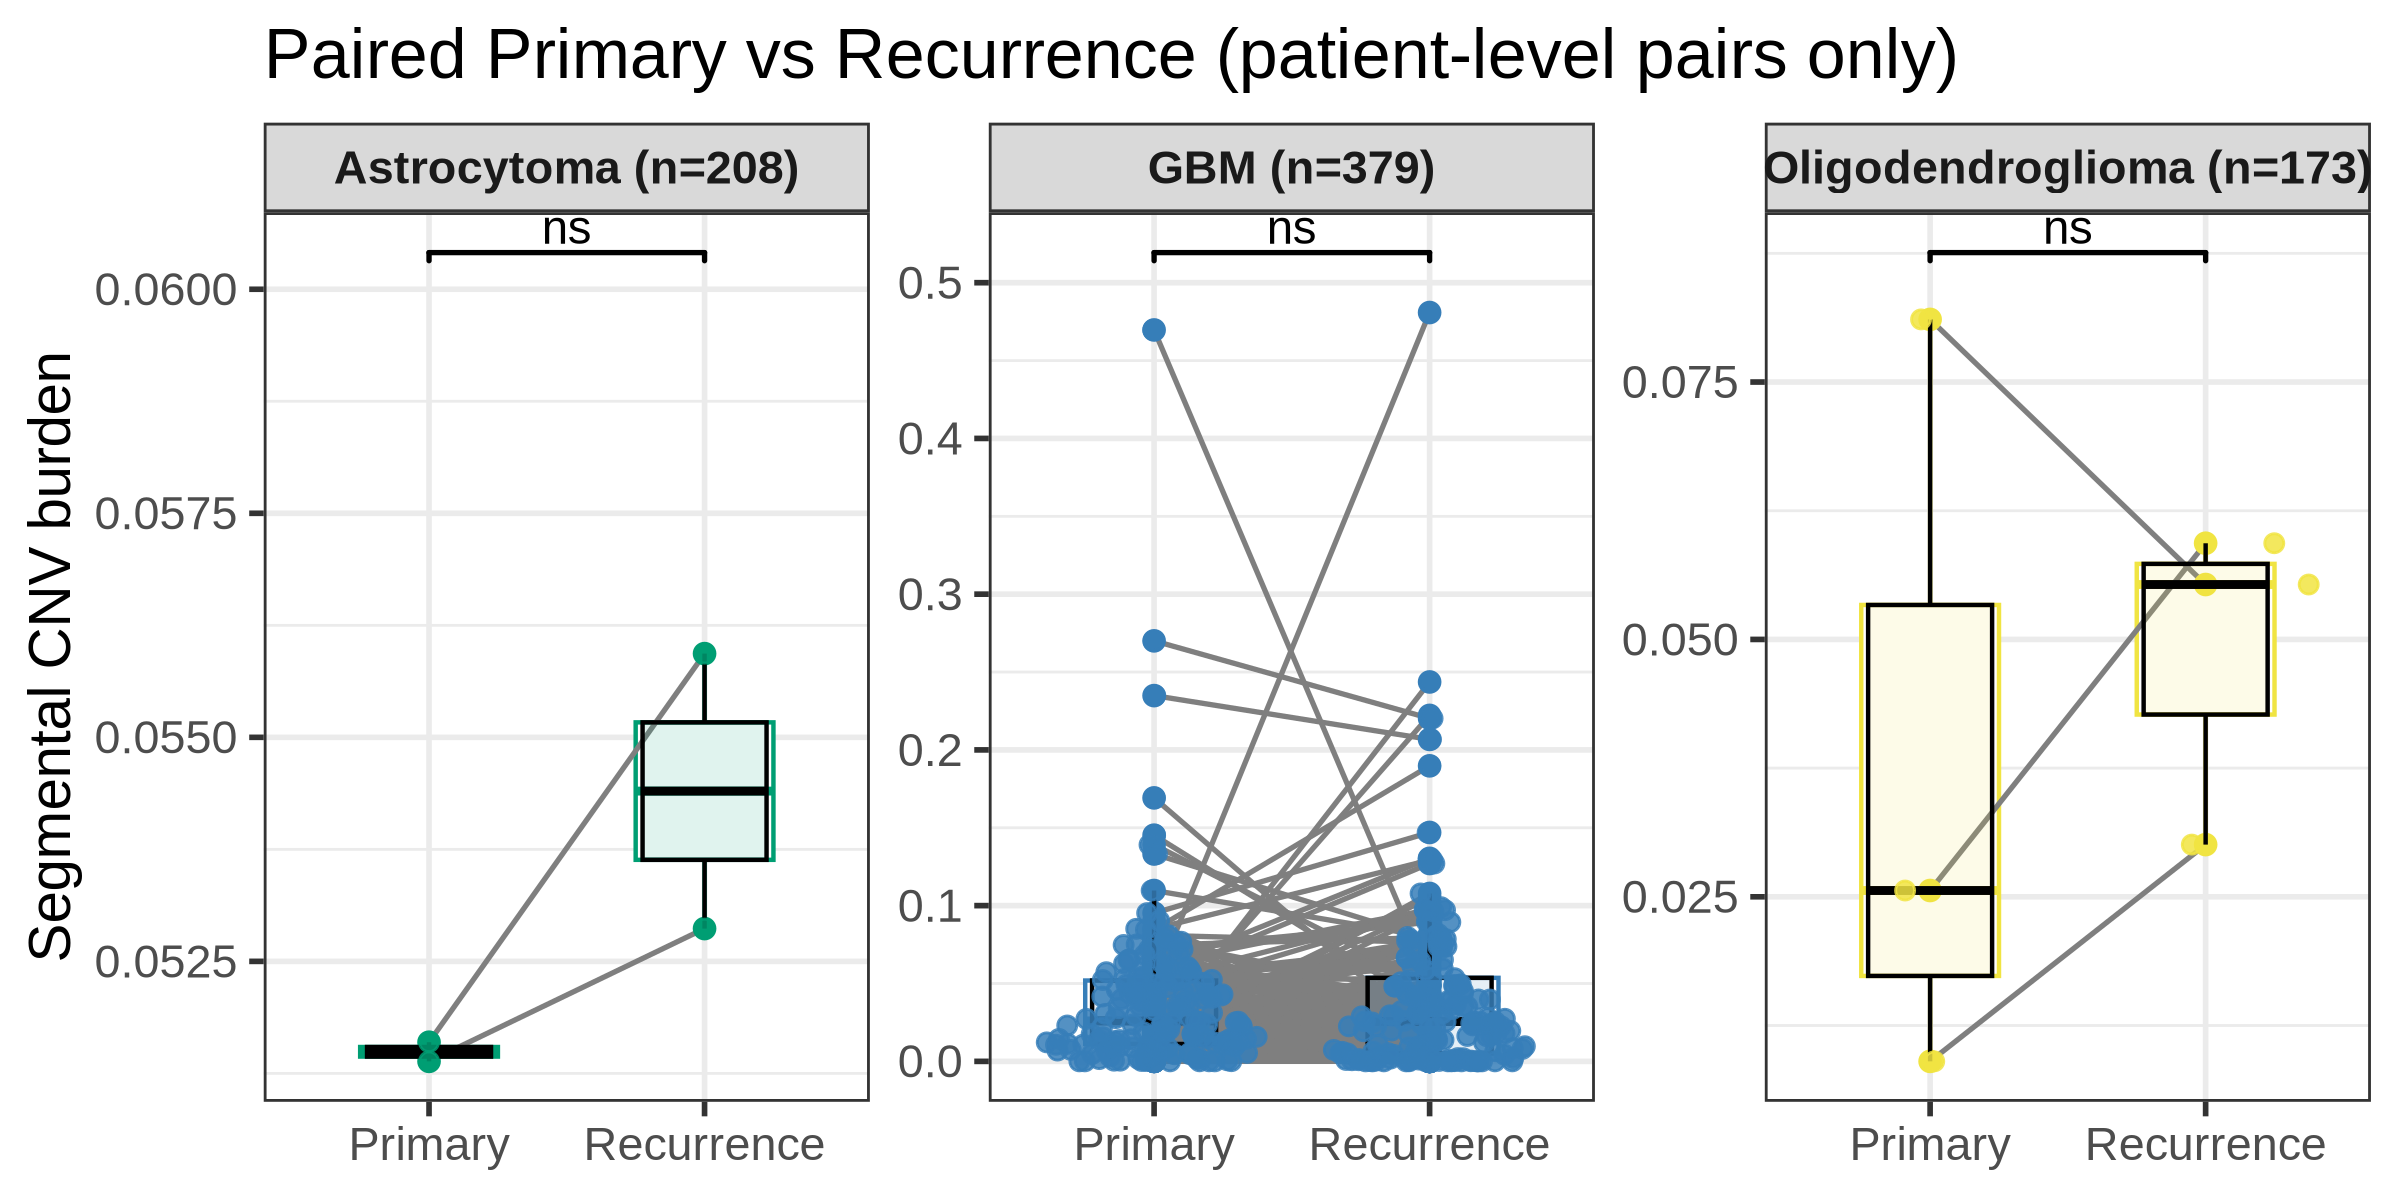

In [216]:
library(dplyr)
library(stringr)
library(ggplot2)
library(ggforce)
library(ggpubr)
library(rstatix)
# if you have readr installed, you can use it; base read works too

# --------------------------
# (OPTIONAL) If you DO have a cBioPortal sample-clinical file, read & build cbio_map.
# Otherwise, leave cbio_map <- NULL and the code will fall back safely.
# --------------------------
cbio_map <- NULL
# Example:
# samp <- read.delim("/path/to/data_clinical_sample.txt", sep = "\t",
#                    header = TRUE, comment.char = "#", check.names = FALSE)
# stage_col <- intersect(names(samp), c("SAMPLE_TYPE", "SAMPLE_TYPE_DETAILED"))
# stage_col <- if (length(stage_col)) stage_col[1] else NA_character_
# std_stage <- function(x) {
#   x <- trimws(as.character(x))
#   case_when(
#     x %in% c("Primary Tumor","Primary tumour","Primary") ~ "Primary",
#     x %in% c("Recurrent Tumor","Recurrent tumour","Recurrence","Recurrent") ~ "Recurrence",
#     TRUE ~ NA_character_
#   )
# }
# cbio_map <- samp %>%
#   transmute(
#     ID = .data[["SAMPLE_ID"]],
#     patient_id_cbio = .data[["PATIENT_ID"]],
#     stage_cbio = if (!is.na(stage_col)) std_stage(.data[[stage_col]]) else NA_character_
#   )

# --------------------------
# 1) Start from your data; (optionally) join cbio_map
# --------------------------
dat0 <- dat_stage_burden
if (!is.null(cbio_map)) {
  dat0 <- left_join(dat0, cbio_map, by = "ID")
}

# GUARANTEE these cols exist even if no join happened
if (!"patient_id_cbio" %in% names(dat0)) dat0$patient_id_cbio <- NA_character_
if (!"stage_cbio"      %in% names(dat0)) dat0$stage_cbio      <- NA_character_

# --------------------------
# 2) Fallback derivation (no look-behind regex)
# --------------------------
dat0 <- dat0 %>%
  mutate(
    # patient stem
    patient_id_fallback = case_when(
      str_detect(ID, "^TCGA-") ~ str_extract(ID, "^TCGA-[^-]+-[^-]+"),  # e.g., TCGA-CS-4938
      str_detect(ID, "^GLSS-") ~ sub("-[^-]+$", "", ID),                # e.g., GLSS-19-0266-R1 -> GLSS-19-0266
      TRUE ~ sub("-[^-]+$", "", ID)
    ),
    # TCGA sample code (01=Primary, 02=Recurrence)
    tcga_code = case_when(
      str_detect(ID, "^TCGA-") ~ str_match(ID, "^TCGA-[^-]+-[^-]+-([0-9]{2})")[, 2],
      TRUE ~ NA_character_
    ),
    stage_fallback = case_when(
      tcga_code == "01" ~ "Primary",
      tcga_code == "02" ~ "Recurrence",
      str_detect(ID, "[-_]R[0-9]*$") ~ "Recurrence",  # GLSS-...-R1, etc.
      str_detect(ID, "[-_]P[0-9]*$") ~ "Primary",     # GLSS-...-P1, etc.
      TRUE ~ NA_character_
    )
  )

# --------------------------
# 3) Final IDs/stage, collapse replicates, keep true pairs
# --------------------------
dat_pairs <- dat0 %>%
  mutate(
    patient_id = coalesce(patient_id_cbio, patient_id_fallback),
    stage_final = factor(
      coalesce(stage_cbio, as.character(stage), stage_fallback),
      levels = c("Primary", "Recurrence")
    )
  ) %>%
  filter(!is.na(patient_id), !is.na(stage_final)) %>%
  group_by(patient_id, tumor_type, stage_final) %>%
  summarise(segmental_cnv_burden = mean(segmental_cnv_burden, na.rm = TRUE), .groups = "drop") %>%
  group_by(patient_id, tumor_type) %>%
  filter(n_distinct(stage_final) == 2) %>%  # keep only true pairs per tumor type
  ungroup()

# (optional sanity check)
dat_pairs %>% count(tumor_type, patient_id) %>% count(tumor_type, name = "n_paired_patients") %>% print()

# --------------------------
# 4) Paired Wilcoxon within tumor type
# --------------------------
cmp_paired <- dat_pairs %>%
  group_by(tumor_type) %>%
  wilcox_test(segmental_cnv_burden ~ stage_final, paired = TRUE, exact = FALSE) %>%
  add_significance() %>%
  mutate(group1 = "Primary", group2 = "Recurrence") %>%
  left_join(
    dat_pairs %>%
      group_by(tumor_type) %>%
      summarise(y.position = max(segmental_cnv_burden, na.rm = TRUE) * 1.08, .groups = "drop"),
    by = "tumor_type"
  )

# --------------------------
# 5) Plot: ggpaired + dashed connectors + boxplots + p-values
# --------------------------
if (!exists("pal")) {
  pal <- c("Astrocytoma" = "#009E73", "GBM" = "#377EB8", "Oligodendroglioma" = "#F0E442")
}

p_paired <- ggpaired(
  data = dat_pairs,
  x = "stage_final",
  y = "segmental_cnv_burden",
  id = "patient_id",
  color = "tumor_type",
  palette = pal,
  line.color = "grey50",
  line.size  = 0.6,
  line.type  = "dashed",
  point.size = 2
) +
  geom_boxplot(aes(fill = tumor_type),
               width = 0.45, alpha = 0.12, outlier.shape = NA, color = "black") +
  ggforce::geom_sina(aes(color = tumor_type), size = 1.8, alpha = 0.85, maxwidth = 0.8) +
  facet_wrap(~ tumor_type, nrow = 1, scales = "free_y",
             labeller = if (exists("facet_labs2")) labeller(tumor_type = facet_labs2) else labeller()) +
  stat_pvalue_manual(
    cmp_paired,
    label = "p.signif", y.position = "y.position",
    xmin = "group1", xmax = "group2",
    bracket.size = 0.6, tip.length = 0.01, size = 4
  ) +
  scale_x_discrete(limits = c("Primary", "Recurrence")) +
  scale_fill_manual(values = pal) +
  scale_color_manual(values = pal) +
  labs(x = NULL, y = "Segmental CNV burden",
       title = "Paired Primary vs Recurrence (patient-level pairs only)") +
  theme_bw(base_size = 14) +
  theme(legend.position = "none", strip.text = element_text(face = "bold"))

p_paired


In [217]:
head(cnv_with_arms_all)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean,tumor_type,stage,sample,row_id,⋯,side,arm,arm_start,arm_end,arm_length,overlap_start,overlap_end,overlap_len,arm_fraction,cna_status
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TCGA-CS-4938-01,chr1,3218610,91104026,50505,0.0027,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_1,⋯,p,1p,0.00e+00,125000000,125000000,3218610,91104026,87885416,0.703083328,1
2,TCGA-CS-4938-01,chr1,91108204,91109793,2,-1.3703,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_2,⋯,p,1p,0.00e+00,125000000,125000000,91108204,91109793,1589,0.000012712,-1
3,TCGA-CS-4938-01,chr1,91112769,247813706,78501,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_3,⋯,p,1p,0.00e+00,125000000,125000000,91112769,125000000,33887231,0.271097848,1
4,TCGA-CS-4938-01,chr1,91112769,247813706,78501,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_3,⋯,q,1q,1.25e+08,249250621,124250621,125000000,247813706,122813706,0.988435350,1
5,TCGA-CS-4938-01,chr2,484222,106146307,55667,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_4,⋯,p,2p,0.00e+00,93300000,93300000,484222,93300000,92815778,0.994810054,1
6,TCGA-CS-4938-01,chr2,484222,106146307,55667,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_4,⋯,q,2q,9.33e+07,243199373,149899373,93300000,106146307,12846307,0.085699538,1


In [218]:
library(dplyr)
library(tidyr)
library(purrr)

# --------------------------
# PARAMETERS
# --------------------------
aneuploidy_threshold <- 0.80   # arm-level threshold (Taylor-like)
segmean_threshold    <- 0.20   # |seg.mean| to call a segment "altered" if cna_status is unreliable
prefer_cna_status    <- FALSE  # set TRUE if cna_status is trustworthy (nonzero = altered)
eps                  <- 1e-6   # pseudocount for log2 fold

# --------------------------
# INPUT -> per-segment rows with arm overlaps
# Required: ID, tumor_type, stage, arm, arm_length, overlap_len, seg.mean, (optional) cna_status
# --------------------------
df <- cnv_with_arms_all %>%
  mutate(
    arm_length  = as.numeric(arm_length),
    overlap_len = as.numeric(overlap_len),
    seg.mean    = as.numeric(seg.mean),
    cna_status  = suppressWarnings(as.numeric(cna_status)),
    # Normalize stage labels
    stage = case_when(
      grepl("prim", tolower(stage)) ~ "Primary",
      grepl("rec",  tolower(stage)) ~ "Recurrence",
      TRUE ~ stage
    )
  ) %>%
  filter(stage %in% c("Primary","Recurrence")) %>%
  mutate(
    is_altered = if (prefer_cna_status && any(!is.na(cna_status))) {
      cna_status != 0
    } else {
      abs(seg.mean) >= segmean_threshold
    }
  )

# --------------------------
# PER-SAMPLE × ARM summary: fraction altered & aneuploid call
# --------------------------
arm_by_sample <- df %>%
  group_by(ID, tumor_type, stage, arm) %>%
  summarise(
    arm_length = max(arm_length, na.rm = TRUE),
    altered_bp = sum(overlap_len[is_altered], na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    altered_bp   = pmin(altered_bp, arm_length),
    frac_altered = ifelse(is.finite(arm_length) & arm_length > 0,
                          altered_bp / arm_length, NA_real_),
    is_aneuploid = frac_altered >= aneuploidy_threshold
  )

# --------------------------
# DELTA GENOME INSTABILITY per tumor_type × arm
#   Δ = log2( median Recurrence frac_altered + eps / median Primary frac_altered + eps )
#   p-value: Wilcoxon rank-sum (Recurrence vs Primary)
# --------------------------
volcano_df <- arm_by_sample %>%
  filter(!is.na(frac_altered)) %>%
  group_by(tumor_type, arm) %>%
  group_modify(~{
    d <- .x
    xP <- d$frac_altered[d$stage == "Primary"]
    xR <- d$frac_altered[d$stage == "Recurrence"]

    medP <- suppressWarnings(median(xP, na.rm = TRUE))
    medR <- suppressWarnings(median(xR, na.rm = TRUE))

    pval <- tryCatch(
      {
        if (sum(!is.na(xP)) > 0 && sum(!is.na(xR)) > 0) {
          wilcox.test(xR, xP, exact = FALSE)$p.value
        } else {
          NA_real_
        }
      },
      error = function(e) NA_real_
    )

    tibble(
      delta_genome_instability = log2((medR + eps) / (medP + eps)),
      pvalue = pval
    )
  }) %>%
  ungroup() %>%
  select(arm, tumor_type, delta_genome_instability, pvalue) %>%
  arrange(tumor_type, arm)

# Peek / save
head(volcano_df)
# write.csv(volcano_df, "volcano_arm_instability.csv", row.names = FALSE)


arm,tumor_type,delta_genome_instability,pvalue
<chr>,<chr>,<dbl>,<dbl>
10p,Astrocytoma,0.0000000,0.21248351
10q,Astrocytoma,10.0371243,0.01741419
11p,Astrocytoma,-3.8469144,0.03052457
11q,Astrocytoma,-3.6899214,0.41090209
12p,Astrocytoma,0.0000000,0.13950741
12q,Astrocytoma,-0.4473918,0.82553285


In [219]:
nrow(volcano_df)

[1] 122

In [220]:
library(dplyr)
library(ggplot2)
library(ggrepel)

# Palette (same as before)
pal <- c(
  "Astrocytoma"       = "#009E73",
  "GBM"               = "#377EB8",
  "Oligodendroglioma" = "#F0E442"
)

alpha_p <- 0.05

volc <- volcano_df %>%
  filter(!is.na(pvalue), !is.na(delta_genome_instability)) %>%
  mutate(
    tumor_type = factor(tumor_type, levels = names(pal)),
    pvalue = pmax(pvalue, .Machine$double.xmin),     # guard against 0
    #neglog10p = -log10(pvalue),
      neglog10p = -log(pvalue),
    sig = pvalue < alpha_p
  )

# Top 5 significant arms by -log10(p)
top5 <- volc %>%
  filter(sig) %>%
  arrange(desc(neglog10p)) %>%
  slice_head(n = 5)

# Threshold line
thr_y <- -log10(alpha_p)

p_volcano <- ggplot() +
  # non-significant (grey)
  geom_point(
    data = filter(volc, !sig),
    aes(x = delta_genome_instability, y = neglog10p),
    shape = 21, fill = "grey80", color = "grey60", size = 2.2, alpha = 0.8
  ) +
  # significant (colored by tumor_type, black border)
  geom_point(
    data = filter(volc, sig),
    aes(x = delta_genome_instability, y = neglog10p, fill = tumor_type),
    shape = 21, color = "black", size = 2.8, alpha = 0.95
  ) +
  # emphasize top 5
  geom_point(
    data = top5,
    aes(x = delta_genome_instability, y = neglog10p, fill = tumor_type),
    shape = 21, color = "black", size = 4.0
  ) +
  geom_text_repel(
    data = top5,
    aes(x = delta_genome_instability, y = neglog10p, label = arm),
    size = 3.5, fontface = "bold", min.segment.length = 0, seed = 123
  ) +
  # reference lines
  geom_hline(yintercept = thr_y, linetype = 2, linewidth = 0.5, color = "grey40") +
  geom_vline(xintercept = 0,    linetype = 3, linewidth = 0.5, color = "grey40") +
  scale_fill_manual(values = pal) +
  labs(
    x = expression(Delta~"Genomic Instability (log"[2]~" Recurrence / Primary)"),
    y = expression(-log[10]~"(p-value)"),
    title = "Volcano: Δ Genomic Instability by Chromosome Arm",
    subtitle = paste0("Significant = p < ", alpha_p)
  ) +
  theme_bw(base_size = 7) +
  theme(
    legend.position = "none",
    plot.title = element_text(face = "bold")
  )

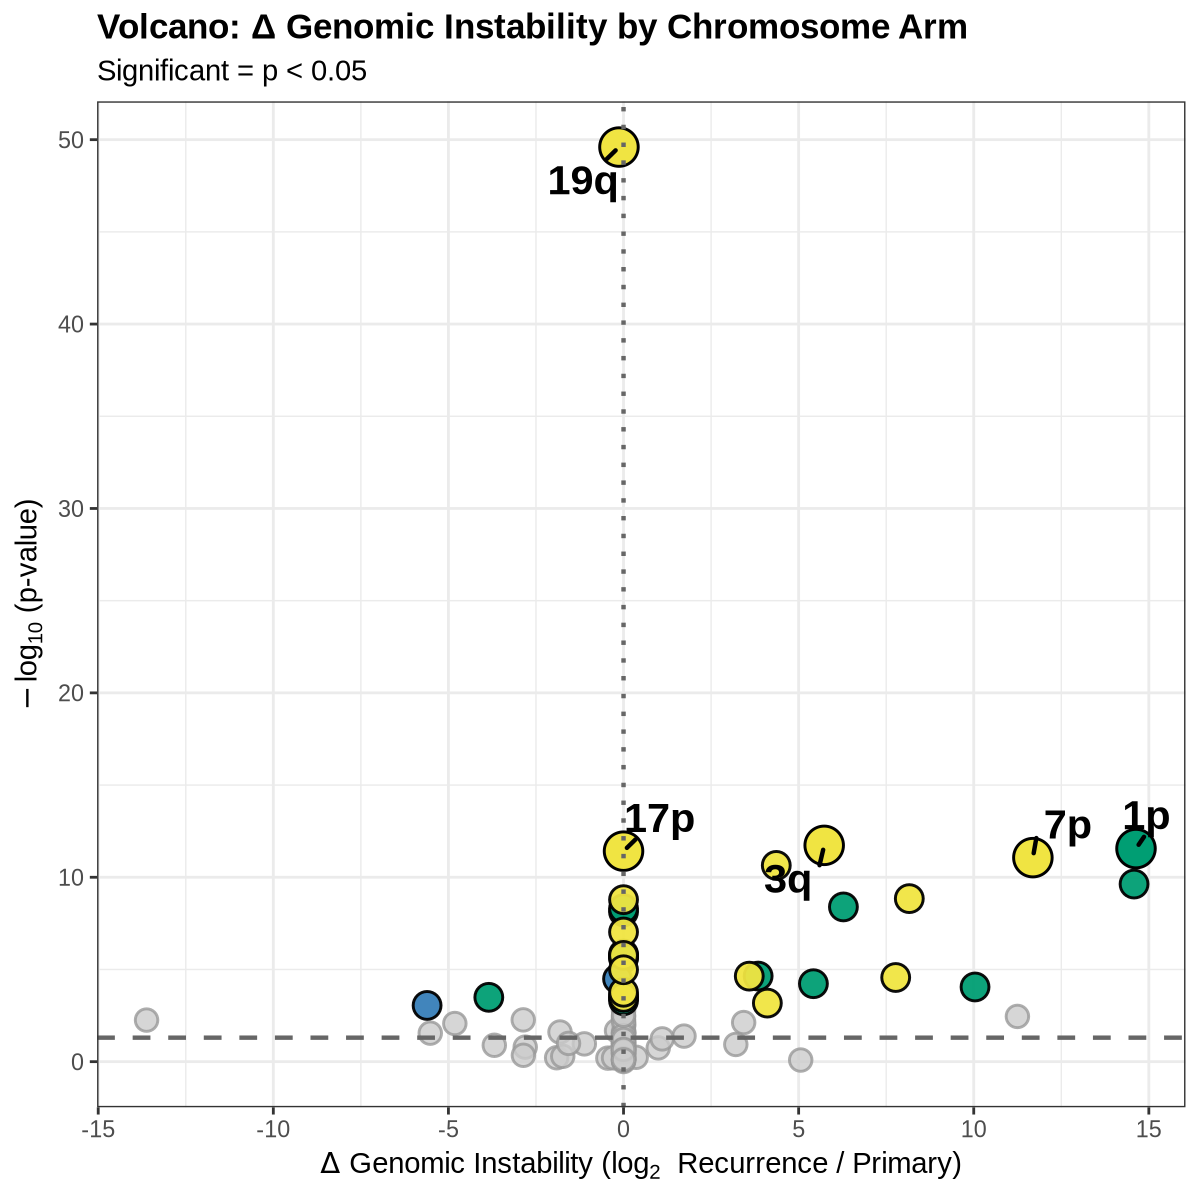

In [221]:
options(repr.plot.width = 4, repr.plot.height = 4, repr.plot.res = 300)

p_volcano

In [222]:
library(dplyr)
library(tidyr)
library(purrr)

# --------------------------
# PARAMETERS
# --------------------------
aneuploidy_threshold <- 0.80
segmean_threshold    <- 0.20
prefer_cna_status    <- FALSE
eps <- 1e-6

# --------------------------
# Build per–sample×arm metrics (continuous & thresholded)
# --------------------------
df <- cnv_with_arms_all %>%
  mutate(
    arm_length  = as.numeric(arm_length),
    overlap_len = as.numeric(overlap_len),
    seg.mean    = as.numeric(seg.mean),
    cna_status  = suppressWarnings(as.numeric(cna_status)),
    stage = case_when(
      grepl("prim", tolower(stage)) ~ "Primary",
      grepl("rec",  tolower(stage)) ~ "Recurrence",
      TRUE ~ stage
    )
  ) %>%
  filter(stage %in% c("Primary","Recurrence")) %>%
  mutate(
    is_altered = if (prefer_cna_status && any(!is.na(cna_status))) {
      cna_status != 0
    } else {
      abs(seg.mean) >= segmean_threshold
    }
  )

arm_by_sample <- df %>%
  group_by(ID, tumor_type, stage, arm) %>%
  summarise(
    arm_length = max(arm_length, na.rm = TRUE),
    # totals
    altered_bp = sum(overlap_len[is_altered], na.rm = TRUE),
    # split by gain/loss (optional; useful later)
    gain_bp = sum(overlap_len[is_altered & seg.mean >  0], na.rm = TRUE),
    loss_bp = sum(overlap_len[is_altered & seg.mean <  0], na.rm = TRUE),
    amp_len = sum(abs(seg.mean[is_altered]) * overlap_len[is_altered], na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    altered_bp   = pmin(altered_bp, arm_length),
    frac_altered = ifelse(arm_length > 0, altered_bp / arm_length, NA_real_),
    frac_gain    = ifelse(arm_length > 0, pmin(gain_bp, arm_length) / arm_length, NA_real_),
    frac_loss    = ifelse(arm_length > 0, pmin(loss_bp, arm_length) / arm_length, NA_real_),
    # "CNA volume" (amplitude × length normalized by arm size)
    cna_volume   = ifelse(arm_length > 0, amp_len / arm_length, NA_real_),
    is_aneuploid = frac_altered >= aneuploidy_threshold
  )

# Helper to get medians and Wilcoxon p-values
wilcox_delta <- function(xP, xR, delta_fun) {
  medP <- suppressWarnings(median(xP, na.rm = TRUE))
  medR <- suppressWarnings(median(xR, na.rm = TRUE))
  pval <- tryCatch({
    if (length(na.omit(xP)) > 0 && length(na.omit(xR)) > 0)
      wilcox.test(xR, xP, exact = FALSE)$p.value else NA_real_
  }, error = function(e) NA_real_)
  tibble(delta = delta_fun(medP, medR), pvalue = pval)
}

# =======================================================
# OPTION A (continuous, threshold-free):
# Δ = median(Recurrence frac_altered) - median(Primary frac_altered)
# Negative -> more instability in Primary; Positive -> more in Recurrence.
# =======================================================
volcano_diff_frac <- arm_by_sample %>%
  group_by(tumor_type, arm) %>%
  group_modify(~{
    d <- .x
    xP <- d$frac_altered[d$stage == "Primary"]
    xR <- d$frac_altered[d$stage == "Recurrence"]
    wilcox_delta(xP, xR, function(mP,mR) mR - mP)
  }) %>%
  ungroup() %>%
  transmute(arm, tumor_type,
            delta_genome_instability = delta,
            pvalue)

# =======================================================
# OPTION B (amplitude-aware):
# Use "CNA volume" = sum(|seg.mean|*bp)/arm_length per sample-arm.
# Δ = log2( median(Recurrence)+eps / median(Primary)+eps )
# Captures both breadth and amplitude of CNAs.
# =======================================================
volcano_log2_cnavol <- arm_by_sample %>%
  group_by(tumor_type, arm) %>%
  group_modify(~{
    d <- .x
    xP <- d$cna_volume[d$stage == "Primary"]
    xR <- d$cna_volume[d$stage == "Recurrence"]
    out <- wilcox_delta(xP, xR, function(mP,mR) log2((mR + eps)/(mP + eps)))
    out
  }) %>%
  ungroup() %>%
  transmute(arm, tumor_type,
            delta_genome_instability = delta,
            pvalue)

# =======================================================
# OPTION C (event-frequency view, Taylor-like):
# Compare odds of arm-level aneuploidy (≥80% altered) across stages.
# Δ = log2(OR) with Fisher’s exact test p-value.
# Negative -> aneuploidy more common in Primary; Positive -> more in Recurrence.
# =======================================================
volcano_log2_or_aneuploid <- arm_by_sample %>%
  group_by(tumor_type, arm) %>%
  group_modify(~{
    d <- .x
    a <- sum(d$is_aneuploid & d$stage == "Recurrence", na.rm = TRUE)
    b <- sum(!d$is_aneuploid & d$stage == "Recurrence", na.rm = TRUE)
    c <- sum(d$is_aneuploid & d$stage == "Primary",    na.rm = TRUE)
    e <- sum(!d$is_aneuploid & d$stage == "Primary",    na.rm = TRUE)

    mat <- matrix(c(a, b, c, e), nrow = 2, byrow = TRUE,
                  dimnames = list(Stage = c("Recurrence","Primary"),
                                   Aneuploid = c("Yes","No")))
    pval <- tryCatch(fisher.test(mat)$p.value, error = function(x) NA_real_)
    # Haldane–Anscombe correction for zeros
    log2OR <- log2(((a + 0.5)/(b + 0.5)) / ((c + 0.5)/(e + 0.5)))
    tibble(delta_genome_instability = log2OR, pvalue = pval)
  }) %>%
  ungroup() %>%
  select(arm, tumor_type, delta_genome_instability, pvalue)

# --------------------------
# Pick the metric you prefer:
#   volcano_diff_frac         # difference in fractions (breadth only)
#   volcano_log2_cnavol       # amplitude-aware (breadth × amplitude)
#   volcano_log2_or_aneuploid # arm-level event odds (thresholded)
# --------------------------

# Example: save one for plotting
# write.csv(volcano_log2_cnavol, "volcano_log2_cnavol.csv", row.names = FALSE)


In [223]:
head(volcano_diff_frac)

arm,tumor_type,delta_genome_instability,pvalue
<chr>,<chr>,<dbl>,<dbl>
10p,Astrocytoma,0.000000e+00,0.21248351
10q,Astrocytoma,1.678933e-02,0.01741419
11p,Astrocytoma,-1.338920e-05,0.03052457
11q,Astrocytoma,-1.190556e-05,0.41090209
12p,Astrocytoma,0.000000e+00,0.13950741
12q,Astrocytoma,-1.101458e-06,0.82553285


In [224]:
#volcano_df = volcano_diff_frac
#volcano_df = volcano_log2_cnavol
volcano_df = volcano_log2_or_aneuploid

In [225]:
library(dplyr)
library(ggplot2)
library(ggrepel)

# Palette (same as before)
pal <- c(
  "Astrocytoma"       = "#009E73",
  "GBM"               = "#377EB8",
  "Oligodendroglioma" = "#F0E442"
)

alpha_p <- 0.05

volc <- volcano_df %>%
  filter(!is.na(pvalue), !is.na(delta_genome_instability)) %>%
  mutate(
    tumor_type = factor(tumor_type, levels = names(pal)),
    pvalue = pmax(pvalue, .Machine$double.xmin),     # guard against 0
    neglog10p = -log10(pvalue),
      #neglog10p = -log(pvalue),
    sig = pvalue < alpha_p
  )

# Top 5 significant arms by -log10(p)
top5 <- volc %>%
  filter(sig) %>%
  arrange(desc(neglog10p)) %>%
  slice_head(n = 10)

# Threshold line
thr_y <- -log10(alpha_p)

p_volcano <- ggplot() +
  # non-significant (grey)
  geom_point(
    data = filter(volc, !sig),
    aes(x = delta_genome_instability, y = neglog10p),
    shape = 21, fill = "grey80", color = "grey60", size = 2.2, alpha = 0.8
  ) +
  # significant (colored by tumor_type, black border)
  geom_point(
    data = filter(volc, sig),
    aes(x = delta_genome_instability, y = neglog10p, fill = tumor_type),
    shape = 21, color = "black", size = 2.8, alpha = 0.95
  ) +
  # emphasize top 5
  geom_point(
    data = top5,
    aes(x = delta_genome_instability, y = neglog10p, fill = tumor_type),
    shape = 21, color = "black", size = 4.0
  ) +
  geom_text_repel(
    data = top5,
    aes(x = delta_genome_instability, y = neglog10p, label = arm),
    size = 3.5, fontface = "bold", min.segment.length = 0, seed = 123
  ) +
  # reference lines
  geom_hline(yintercept = thr_y, linetype = 2, linewidth = 0.5, color = "grey40") +
  #geom_vline(xintercept = 0,    linetype = 3, linewidth = 0.5, color = "grey40") +
  scale_fill_manual(values = pal) +
  labs(
    x = expression(Delta~"Genomic Instability (log"[2]~" OR)"),
    y = expression(-log[10]~"(p-value)"),
    title = "Volcano: Δ Genomic Instability by Chromosome Arm",
    subtitle = paste0("Significant = p < ", alpha_p)
  ) +
  theme_bw(base_size = 7) +
  theme(
    legend.position = "none",
    plot.title = element_text(face = "bold")
  )

In [226]:
setwd("/home//mjehangir/telomere-sv-analysis/plots/TCGA_plots/")

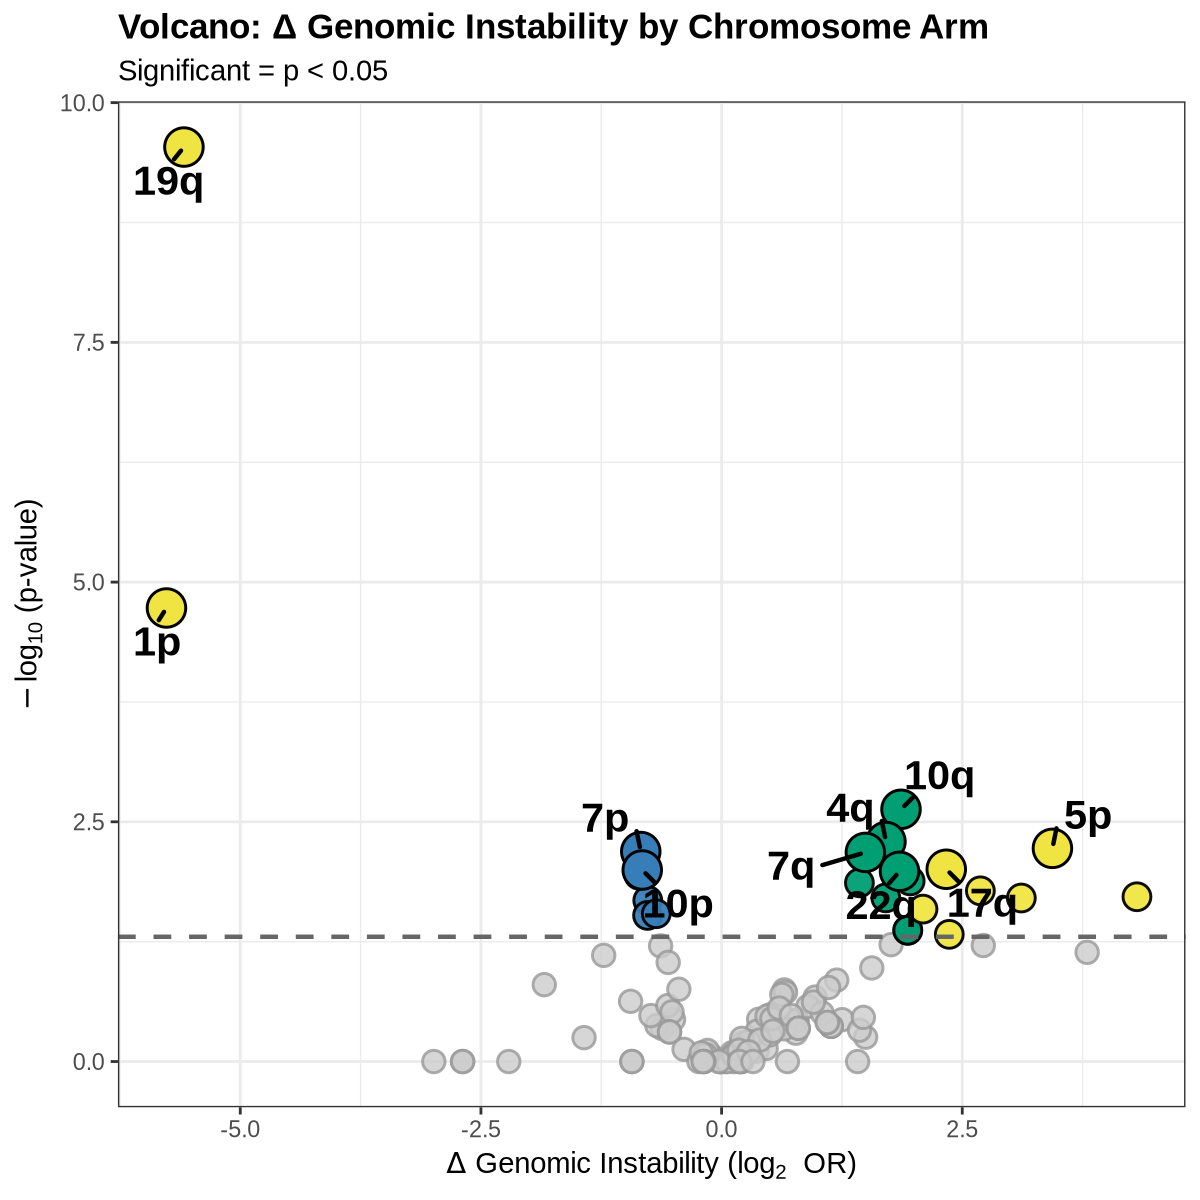

In [227]:
options(repr.plot.width = 4, repr.plot.height = 4, repr.plot.res = 300)

#pdf("volcano_plot_revised.pdf", width = 4, height = 4)

p_volcano

#dev.off()

In [228]:
arm_level_cnvs <- cnv_with_arms %>%
  #filter(arm_fraction >= 0.8 & abs(seg.mean) >= arm_level_threshold) %>%
    filter(arm_fraction >= 0.8 & abs(seg.mean) >= 0.3) %>%
  select(sample, tumor_type, stage, chrom, arm, cna_status) %>%
  unite(region, chrom, arm, sep = "_")

partial_cnvs <- cnv_with_arms %>%
  #filter(arm_fraction < 0.8 & arm_fraction > 0 & abs(seg.mean) >= arm_level_threshold) %>%
    #filter(arm_fraction < 0.79 & arm_fraction > 0.01 & abs(seg.mean) >= arm_level_threshold) %>%
    filter(arm_fraction < 0.80 & arm_fraction > 0.01 & abs(seg.mean) >= arm_level_threshold) %>%
  select(sample, tumor_type, stage, chrom, arm, cna_status) %>%
  unite(region, chrom, arm, sep = "_")


In [229]:
head(cnv_with_arms)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean,tumor_type,stage,sample,row_id,⋯,side,arm,arm_start,arm_end,arm_length,overlap_start,overlap_end,overlap_len,arm_fraction,cna_status
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,TCGA-CS-4938-01,chr1,3218610,91104026,50505,0.0027,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_1,⋯,p,1p,0.00e+00,125000000,125000000,3218610,91104026,87885416,0.703083328,1
2,TCGA-CS-4938-01,chr1,91108204,91109793,2,-1.3703,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_2,⋯,p,1p,0.00e+00,125000000,125000000,91108204,91109793,1589,0.000012712,-1
3,TCGA-CS-4938-01,chr1,91112769,247813706,78501,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_3,⋯,p,1p,0.00e+00,125000000,125000000,91112769,125000000,33887231,0.271097848,1
4,TCGA-CS-4938-01,chr1,91112769,247813706,78501,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_3,⋯,q,1q,1.25e+08,249250621,124250621,125000000,247813706,122813706,0.988435350,1
5,TCGA-CS-4938-01,chr2,484222,106146307,55667,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_4,⋯,p,2p,0.00e+00,93300000,93300000,484222,93300000,92815778,0.994810054,1
6,TCGA-CS-4938-01,chr2,484222,106146307,55667,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_4,⋯,q,2q,9.33e+07,243199373,149899373,93300000,106146307,12846307,0.085699538,1


In [230]:
nrow(cnv_with_arms)

[1] 112116

In [231]:
unique(cnv_with_arms$tumor_type)

[1] "Astrocytoma"       "GBM"               "Oligodendroglioma"

In [232]:
library(dplyr)
library(tidyr)

arm_level_mat <- arm_level_cnvs %>%
  group_by(sample, region) %>%
  summarise(cna_status = max(abs(cna_status)) * sign(cna_status[cna_status != 0][1]), .groups = "drop") %>%
  pivot_wider(names_from = region, values_from = cna_status, values_fill = 0) %>%
  column_to_rownames("sample") %>%
  as.matrix()


In [233]:
partial_mat <- partial_cnvs %>%
  group_by(sample, region) %>%
  summarise(cna_status = max(abs(cna_status)) * sign(cna_status[cna_status != 0][1]), .groups = "drop") %>%
  pivot_wider(names_from = region, values_from = cna_status, values_fill = 0) %>%
  column_to_rownames("sample") %>%
  as.matrix()
head(partial_mat)

,chr10_10p,chr10_10q,chr17_17q,chr1_1q,chr21_21p,chr3_3p,chr9_9p,chr14_14q,chr15_15q,chr19_19q,⋯,chr13_13q,chr17_17p,chr18_18p,chr12_12p,chr2_2q,chr20_20q,chr16_16q,chr5_5q,chr20_20p,chr5_5p
GLSS-19-0266-TP,-1,-1,-1,-1,-1,-1,-1,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
GLSS-19-0267-TP,0,-1,0,0,1,0,-1,1,1,1,⋯,0,0,0,0,0,0,0,0,0,0
GLSS-19-0268-TP,-1,-1,0,0,1,0,-1,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
GLSS-19-0269-TP,-1,-1,0,0,1,0,1,-1,0,0,⋯,0,0,0,0,0,0,0,0,0,0
GLSS-19-0270-TP,-1,-1,0,0,0,0,-1,-1,-1,1,⋯,0,0,0,0,0,0,0,0,0,0
GLSS-19-0271-TP,-1,-1,0,0,-1,0,-1,0,0,1,⋯,0,0,0,0,0,0,0,0,0,0


In [234]:
#head(partial_mat)

In [235]:
library(tidyverse)
library(ComplexHeatmap)
library(circlize)
library(cowplot)

# --- Assuming these data frames exist from your previous steps: ---
# arm_level_cnvs (columns: sample, tumor_type, stage, region, cna_status)
# partial_cnvs (same columns)
# measures (sample, tumor_type, stage, aneuploidy_fraction, percent_genome_altered)

# --- Step 1: Prepare matrices for heatmaps ---

arm_level_mat <- arm_level_cnvs %>%
  group_by(sample, region) %>%
  summarise(cna_status = first(cna_status), .groups = "drop") %>%
  pivot_wider(names_from = region, values_from = cna_status, values_fill = 0) %>%
  column_to_rownames("sample") %>%
  as.matrix()

partial_mat <- partial_cnvs %>%
  group_by(sample, region) %>%
  summarise(cna_status = first(cna_status), .groups = "drop") %>%
  pivot_wider(names_from = region, values_from = cna_status, values_fill = 0) %>%
  column_to_rownames("sample") %>%
  as.matrix()

# --- Step 2: Get common samples to match rows in both matrices ---

common_samples <- intersect(rownames(arm_level_mat), rownames(partial_mat))

arm_level_mat_sub <- arm_level_mat[common_samples, , drop = FALSE]
partial_mat_sub <- partial_mat[common_samples, , drop = FALSE]

# --- Helper function to get tumor type in correct order ---
get_tumor_type <- function(samples, df) {
  df %>%
    distinct(sample, tumor_type) %>%
    filter(sample %in% samples) %>%
    arrange(factor(sample, levels = samples)) %>%
    pull(tumor_type)
}

tumor_colors <- c("GBM" = "#E41A1C", "Astrocytoma" = "#377EB8", "Oligodendroglioma" = "#4DAF4A")

# --- Step 3: Create row annotations for subset samples ---

ha_arm_row_sub <- rowAnnotation(
  TumorType = factor(get_tumor_type(common_samples, arm_level_cnvs),
                     levels = names(tumor_colors)),
  col = list(TumorType = tumor_colors),
  show_annotation_name = TRUE
)

ha_partial_row_sub <- rowAnnotation(
  TumorType = factor(get_tumor_type(common_samples, partial_cnvs),
                     levels = names(tumor_colors)),
  col = list(TumorType = tumor_colors),
  show_annotation_name = TRUE
)

# --- Step 4: Define CNA color function ---
col_fun <- colorRamp2(c(-1, 0, 1), c("darkblue", "lightyellow1", "orangered"))


In [236]:
head(df)

,ID,chrom,loc.start,loc.end,num.mark,seg.mean,tumor_type,stage,sample,row_id,⋯,arm,arm_start,arm_end,arm_length,overlap_start,overlap_end,overlap_len,arm_fraction,cna_status,is_altered
,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
1,TCGA-CS-4938-01,chr1,3218610,91104026,50505,0.0027,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_1,⋯,1p,0.00e+00,125000000,125000000,3218610,91104026,87885416,0.703083328,1,FALSE
2,TCGA-CS-4938-01,chr1,91108204,91109793,2,-1.3703,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_2,⋯,1p,0.00e+00,125000000,125000000,91108204,91109793,1589,0.000012712,-1,TRUE
3,TCGA-CS-4938-01,chr1,91112769,247813706,78501,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_3,⋯,1p,0.00e+00,125000000,125000000,91112769,125000000,33887231,0.271097848,1,FALSE
4,TCGA-CS-4938-01,chr1,91112769,247813706,78501,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_3,⋯,1q,1.25e+08,249250621,124250621,125000000,247813706,122813706,0.988435350,1,FALSE
5,TCGA-CS-4938-01,chr2,484222,106146307,55667,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_4,⋯,2p,0.00e+00,93300000,93300000,484222,93300000,92815778,0.994810054,1,FALSE
6,TCGA-CS-4938-01,chr2,484222,106146307,55667,0.0023,Astrocytoma,Primary,TCGA-CS-4938-01,astro_primary.seg_4,⋯,2q,9.33e+07,243199373,149899373,93300000,106146307,12846307,0.085699538,1,FALSE


In [237]:


# Get tumor type factor in the order of the rows
row_split_factor <- factor(get_tumor_type(common_samples, arm_level_cnvs),
                           levels = c("GBM", "Astrocytoma", "Oligodendroglioma"))

options(repr.plot.width = 15, repr.plot.height = 10, repr.plot.res = 200)

ht_arm_sub <- Heatmap(arm_level_mat_sub,
                      name = "Arm-level CNA",
                      col = col_fun,
                      right_annotation = ha_arm_row_sub,
                      show_row_names = FALSE,
                      cluster_rows = FALSE,
                      cluster_columns = FALSE,
                      column_title = "Arm-level CNAs",
                      row_split = row_split_factor,
                      row_title = NULL,   # optionally hide row titles if you want
                      cluster_row_slices = TRUE)  # cluster rows within each slice

ht_partial_sub <- Heatmap(partial_mat_sub,
                         name = "Partial CNA",
                         col = col_fun,
                         right_annotation = ha_partial_row_sub,
                         show_row_names = FALSE,
                         cluster_rows = FALSE,
                         cluster_columns = FALSE,
                         column_title = "Partial CNAs",
                         row_split = row_split_factor,
                         row_title = NULL,
                         cluster_row_slices = TRUE)
     


In [238]:
# --- Step 6: Boxplots for genomic instability metrics ---

#measures_filt <- measures %>%
#  filter(tumor_type %in% c("Astrocytoma", "GBM", "Oligodendroglioma"))

In [239]:
# Step 1: Define desired chromosome arm order (1p, 1q, ..., Xp, Xq)
arm_order <- paste0(rep(c(1:22, "X", "Y"), each = 2), rep(c("p", "q"), times = 24))

# Step 2: Clean up column names to 1p, 1q, etc.
clean_colnames <- function(cols) {
  cols <- gsub("^chr(\\d+)_\\1", "\\1", cols)  # chr7_7p → 7p
  cols <- gsub("^chrX_X", "X", cols)
  cols <- gsub("^chrY_Y", "Y", cols)
  return(cols)
}

# Apply to both matrices
colnames(arm_level_mat_sub) <- clean_colnames(colnames(arm_level_mat_sub))
colnames(partial_mat_sub) <- clean_colnames(colnames(partial_mat_sub))

# Step 3: Reorder columns based on desired arm order
# Keep only columns that exist in the matrix and in our defined order
valid_arm_cols <- intersect(arm_order, colnames(arm_level_mat_sub))
arm_level_mat_sub <- arm_level_mat_sub[, valid_arm_cols]

valid_partial_cols <- intersect(arm_order, colnames(partial_mat_sub))
partial_mat_sub <- partial_mat_sub[, valid_partial_cols]


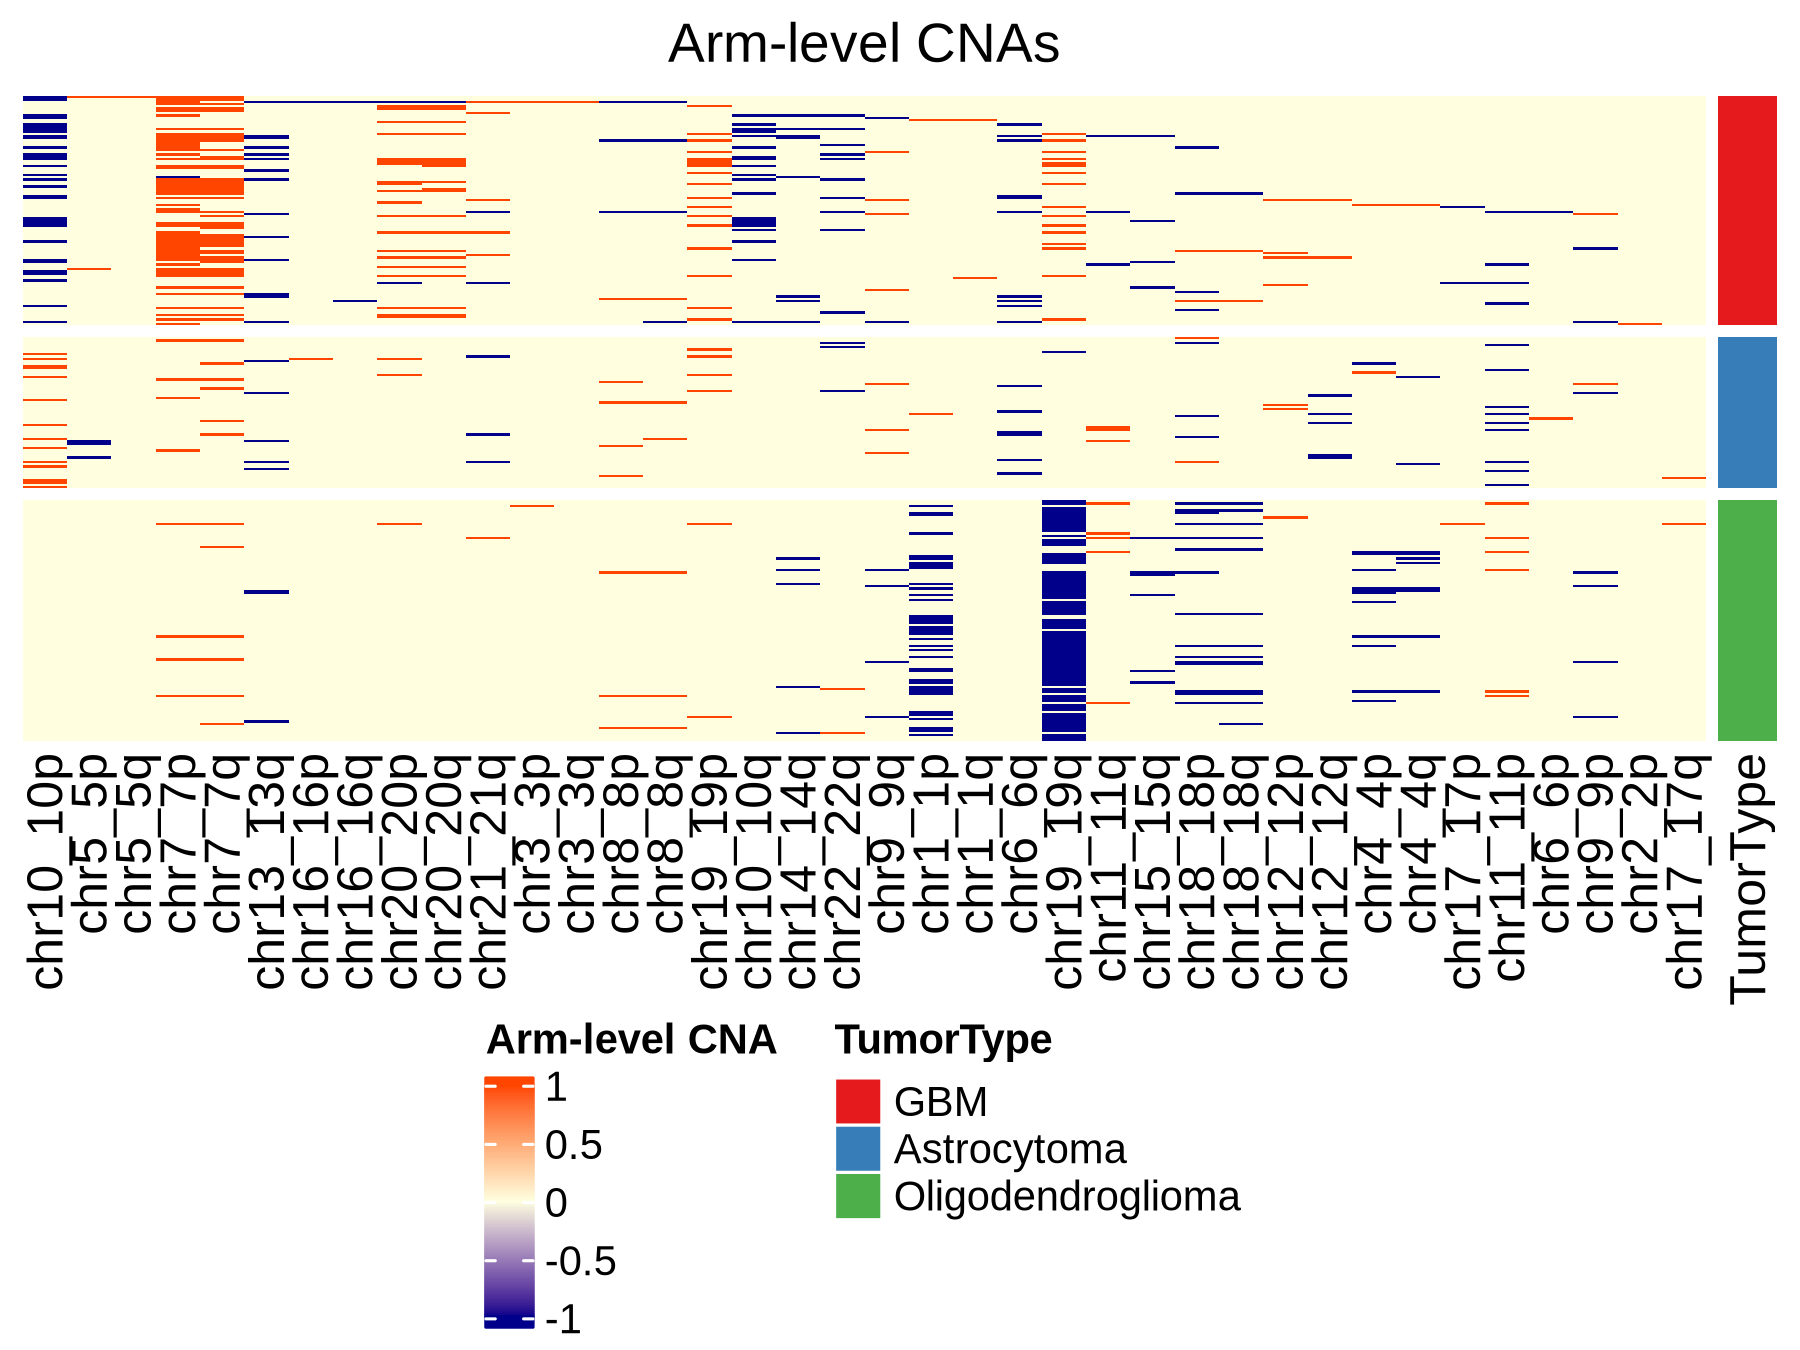

In [240]:
options(repr.plot.width = 6, repr.plot.height = 4.5, repr.plot.res = 300)
#draw(ht_arm_sub + ht_partial_sub, heatmap_legend_side = "bottom")
draw(ht_arm_sub, heatmap_legend_side = "bottom")

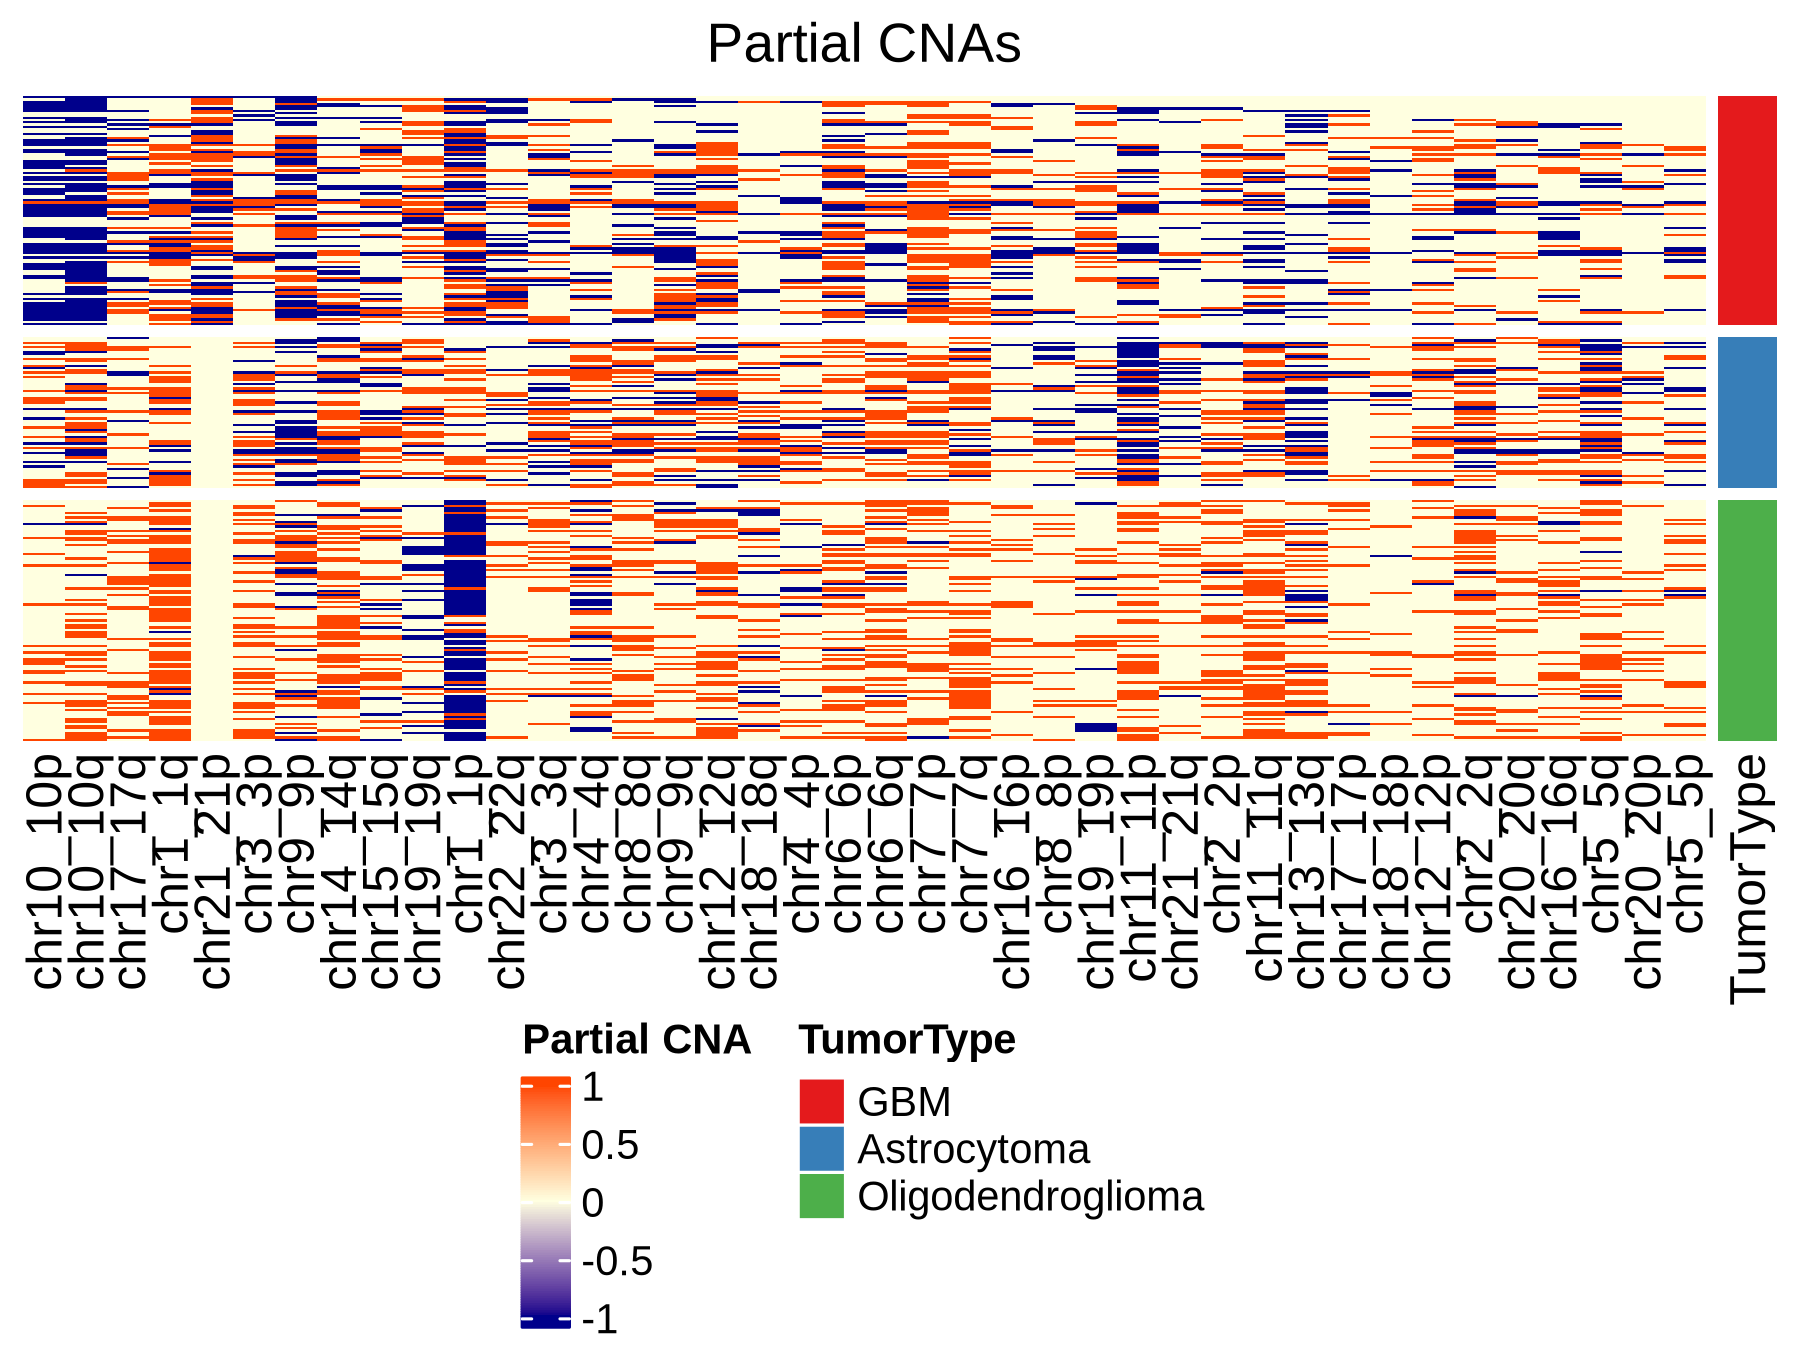

In [241]:
#draw(ht_arm_sub + ht_partial_sub, heatmap_legend_side = "bottom")
draw(ht_partial_sub, heatmap_legend_side = "bottom")

In [242]:
head(partial_cnvs)

,sample,tumor_type,stage,region,cna_status
,<chr>,<chr>,<chr>,<chr>,<dbl>
1,TCGA-CS-4938-01,Astrocytoma,Primary,chr7_7q,1
2,TCGA-CS-4938-01,Astrocytoma,Primary,chr7_7q,-1
3,TCGA-CS-4938-01,Astrocytoma,Primary,chr11_11p,-1
4,TCGA-CS-4938-01,Astrocytoma,Primary,chr12_12p,1
5,TCGA-CS-4938-01,Astrocytoma,Primary,chr12_12p,1
6,TCGA-CS-4938-01,Astrocytoma,Primary,chr12_12q,1


In [243]:
head(arm_level_cnvs)

,sample,tumor_type,stage,region,cna_status
,<chr>,<chr>,<chr>,<chr>,<dbl>
1,TCGA-CS-4938-01,Astrocytoma,Primary,chr18_18p,1
2,TCGA-CS-4942-01,Astrocytoma,Primary,chr7_7p,1
3,TCGA-CS-4942-01,Astrocytoma,Primary,chr7_7q,1
4,TCGA-CS-4943-01,Astrocytoma,Primary,chr18_18p,-1
5,TCGA-CS-4943-01,Astrocytoma,Primary,chr22_22q,-1
6,TCGA-CS-6665-01,Astrocytoma,Primary,chr11_11p,-1
